# Import Packages

In [1]:
# !pip install holidays
# !pip install plotly
# !pip install pmdarima
# !pip install xgboost

In [2]:
pip install holidays numpy pandas matplotlib pmdarima statsmodels scikit-learn xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import holidays
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from typing import Tuple

In [4]:
# Safe check for installed packages
packages = ["holidays", "plotly", "pmdarima", "xgboost"]

for pkg in packages:
    try:
        module = __import__(pkg)
        print(f"{pkg} is installed, version: {module.__version__}")
    except ModuleNotFoundError:
        print(f"{pkg} is NOT installed")
    except AttributeError:
        # Some packages like xgboost may use 'XGBRegressor.__version__' differently
        print(f"{pkg} is installed, but version info not available")

holidays is installed, version: 0.93
plotly is installed, version: 5.24.1
pmdarima is installed, version: 2.1.1
xgboost is installed, version: 3.2.0


# Data Import

In [5]:
import pandas as pd

df_customers = pd.read_csv(r"C:\Users\MostafaSalem/ThesisProject/Dataset/dim_customers.csv")
df_merchants = pd.read_csv(r"C:\Users\MostafaSalem/ThesisProject/Dataset/dim_merchants.csv")
df_products = pd.read_csv(r"C:\Users\MostafaSalem/ThesisProject/Dataset/dim_products.csv")
df_purchaselines = pd.read_csv(r"C:\Users\MostafaSalem/ThesisProject/Dataset/dim_purchaselines.csv")
df_purchase_payments = pd.read_csv(r"C:\Users\MostafaSalem/ThesisProject/Dataset/fact_purchase_payments.csv")
df_purchase_reviews = pd.read_csv(r"C:\Users\MostafaSalem/ThesisProject/Dataset/fact_purchase_reviews.csv")
df_purchases = pd.read_csv(r"C:\Users\MostafaSalem/ThesisProject/Dataset/fact_purchases.csv")

In [6]:
print(df_customers.shape)
print(df_merchants.shape)
print(df_products.shape)
print(df_purchaselines.shape)
print(df_purchase_payments.shape)
print(df_purchase_reviews.shape)
print(df_purchases.shape)

(99441, 5)
(3095, 4)
(32951, 9)
(112650, 9)
(103886, 5)
(99224, 5)
(99441, 8)


In [7]:
dfs = {
    "customers": df_customers,
    "merchants": df_merchants,
    "products": df_products,
    "purchaselines": df_purchaselines,
    "purchase_payments": df_purchase_payments,
    "purchase_reviews": df_purchase_reviews,
    "purchases": df_purchases
}

for name, df in dfs.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
merchants: (3095, 4)
products: (32951, 9)
purchaselines: (112650, 9)
purchase_payments: (103886, 5)
purchase_reviews: (99224, 5)
purchases: (99441, 8)


# Data Validation

## 1) Exploratory Data Analysis (Basic Inspection)

In [8]:
df_customers.head(20)

,customer_sk,customer_id,postal_code_prefix,city,state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,RG,Reading,RD
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,LS,Leeds,LD
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,EC,London,LN
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,S,Sheffield,SF
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,B,Birmingham,BM
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,PE,Peterborough,PB
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,EC,London,LN
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,CW,Crewe,CW
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,B,Birmingham,BM
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,B,Birmingham,BM


In [9]:
df_merchants.head(20)

,merchant_id,postal_code_prefix,city,state
0,3442f8959a84dea7ee197c632cb2df15,B,Birmingham,BM
1,d1b65fc7debc3361ea86b5f14c68d2e2,RG,Reading,RD
2,ce3ad9de960102d0677a81f5d0bb7b2d,EC,London,LN
3,c0f3eea2e14555b6faeea3dd58c1b1c3,EC,London,LN
4,51a04a8a6bdcb23deccc82b0b80742cf,OX,Oxford,OX
5,c240c4061717ac1806ae6ee72be3533b,EC,London,LN
6,e49c26c3edfa46d227d5121a6b6e4d37,TQ,Newton Abbot,NE
7,1b938a7ec6ac5061a66a3766e0e75f90,ST16,Stafford,ST
8,768a86e36ad6aae3d03ee3c6433d61df,EC,London,LN
9,ccc4bbb5f32a6ab2b7066a4130f114e3,B,Birmingham,BM


In [10]:
df_products.head(20)

,sku_id,category_name,name_length,description_length,photo_count,weight_g,length_cm,height_cm,width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,musical_instruments,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,furniture_decor,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,home_appliances,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,toys,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


In [11]:
df_purchaselines.head(20)

,purchase_id,line_id,sku_id,merchant_id,dispatch_deadline,selling_price,delivery_fee,unit_cost,price_cost_index
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,19/09/2024 09:45,58.90,13.29,29.4500,0.50
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,03/05/2024 11:05,239.90,19.93,131.9450,0.55
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,18/01/2025 14:48,199.00,17.87,119.4000,0.60
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,15/08/2025 10:10,12.99,12.79,5.8455,0.45
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,13/02/2024 13:57,199.90,18.14,115.9420,0.58
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,23/05/2024 03:55,21.90,12.69,12.0450,0.55
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,14/12/2024 12:10,19.90,11.85,14.3280,0.72
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,10/07/2025 12:30,810.00,70.75,469.8000,0.58
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,26/03/2025 18:31,145.95,11.65,72.9750,0.50
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,06/07/2025 14:10,53.99,11.40,35.0935,0.65


In [12]:
df_purchase_payments.head(20)

,purchase_id,payment_sequence,payment_method,installment_count,payment_amount
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


In [13]:
df_purchase_reviews.head(20)

,review_id,purchase_id,rating_score,review_created_at,review_answered_at
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2025-01-18 00:00:00,2025-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2025-03-10 00:00:00,2025-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2025-02-17 00:00:00,2025-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2024-04-21 00:00:00,2024-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2025-03-01 00:00:00,2025-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,2025-04-13 00:00:00,2025-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,2024-07-16 00:00:00,2024-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,2025-08-14 00:00:00,2025-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,2024-05-17 00:00:00,2024-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,2025-05-22 00:00:00,2025-05-23 16:45:47


In [14]:
df_purchases.head(20)

,purchase_id,customer_sk,purchase_status,purchased_at,approved_at,handed_to_carrier_at,delivered_to_customer_at,expected_delivery_at
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02/10/2024 10:56,02/10/2024 11:07,04/10/2024 19:55,10/10/2024 21:25,18/10/2024 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24/07/2025 20:41,26/07/2025 03:24,26/07/2025 14:31,07/08/2025 15:27,13/08/2025 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08/08/2025 08:38,08/08/2025 08:55,08/08/2025 13:50,17/08/2025 18:06,04/09/2025 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18/11/2024 19:28,18/11/2024 19:45,22/11/2024 13:39,02/12/2024 00:28,15/12/2024 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13/02/2025 21:18,13/02/2025 22:20,14/02/2025 19:46,16/02/2025 18:17,26/02/2025 00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,09/07/2024 21:57,09/07/2024 22:10,11/07/2024 14:58,26/07/2024 10:57,01/08/2024 00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,11/04/2024 12:22,13/04/2024 13:25,NaN,NaN,09/05/2024 00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,16/05/2024 13:10,16/05/2024 13:22,22/05/2024 10:07,26/05/2024 12:55,07/06/2024 00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,23/01/2024 18:29,25/01/2024 02:50,26/01/2024 14:16,02/02/2024 14:08,06/03/2024 00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,29/07/2024 11:55,29/07/2024 12:05,10/08/2024 19:45,16/08/2024 17:14,23/08/2024 00:00


In [15]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_sk         99441 non-null  object
 1   customer_id         99441 non-null  object
 2   postal_code_prefix  99441 non-null  object
 3   city                99441 non-null  object
 4   state               99113 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


In [16]:
df_merchants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   merchant_id         3095 non-null   object
 1   postal_code_prefix  3095 non-null   object
 2   city                3095 non-null   object
 3   state               3095 non-null   object
dtypes: object(4)
memory usage: 96.8+ KB


In [17]:
df_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   purchase_id               99441 non-null  object
 1   customer_sk               99441 non-null  object
 2   purchase_status           99441 non-null  object
 3   purchased_at              99441 non-null  object
 4   approved_at               99281 non-null  object
 5   handed_to_carrier_at      97658 non-null  object
 6   delivered_to_customer_at  96476 non-null  object
 7   expected_delivery_at      99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [18]:
df_purchase_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_id           99224 non-null  object
 1   purchase_id         99224 non-null  object
 2   rating_score        99224 non-null  int64 
 3   review_created_at   99224 non-null  object
 4   review_answered_at  99224 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [19]:
df_purchaselines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   purchase_id        112650 non-null  object 
 1   line_id            112650 non-null  int64  
 2   sku_id             112650 non-null  object 
 3   merchant_id        112650 non-null  object 
 4   dispatch_deadline  112650 non-null  object 
 5   selling_price      112650 non-null  float64
 6   delivery_fee       112650 non-null  float64
 7   unit_cost          112650 non-null  float64
 8   price_cost_index   112650 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 7.7+ MB


In [20]:
df_purchase_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   purchase_id        103886 non-null  object 
 1   payment_sequence   103886 non-null  int64  
 2   payment_method     103886 non-null  object 
 3   installment_count  103886 non-null  int64  
 4   payment_amount     103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [21]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sku_id              32951 non-null  object 
 1   category_name       32341 non-null  object 
 2   name_length         32341 non-null  float64
 3   description_length  32341 non-null  float64
 4   photo_count         32341 non-null  float64
 5   weight_g            32949 non-null  float64
 6   length_cm           32949 non-null  float64
 7   height_cm           32949 non-null  float64
 8   width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


## 2) Missing Values

In [22]:
for name, df in dfs.items():
    print(f"\n{name.upper()} - Missing Values")
    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().sum() / len(df)) * 100
    })
    print(missing[missing["missing_count"] > 0].sort_values("missing_pct", ascending=False))


CUSTOMERS - Missing Values
       missing_count  missing_pct
state            328     0.329844

MERCHANTS - Missing Values
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

PRODUCTS - Missing Values
                    missing_count  missing_pct
category_name                 610     1.851234
name_length                   610     1.851234
description_length            610     1.851234
photo_count                   610     1.851234
weight_g                        2     0.006070
length_cm                       2     0.006070
height_cm                       2     0.006070
width_cm                        2     0.006070

PURCHASELINES - Missing Values
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

PURCHASE_PAYMENTS - Missing Values
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

PURCHASE_REVIEWS - Missing Values
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

PURCHASES - Missing Values
                          missing_count

## 3) Duplicate Rows

In [23]:
for name, df in dfs.items():
    dup_count = df.duplicated().sum()
    print(f"{name}: duplicate rows = {dup_count}")

customers: duplicate rows = 0
merchants: duplicate rows = 0
products: duplicate rows = 0
purchaselines: duplicate rows = 0
purchase_payments: duplicate rows = 0
purchase_reviews: duplicate rows = 0
purchases: duplicate rows = 0


## 4) Column Validation

In [24]:
expected_columns = {
    "customers": ["customer_sk", "customer_id", "postal_code_prefix", "city", "state"],
    "merchants": ["merchant_id"],
    "products": ["sku_id"],
    "purchaselines": ["purchase_id", "line_id", "sku_id", "merchant_id", "dispatch_deadline", "selling_price", "delivery_fee", "unit_cost"],
    "purchase_payments": ["purchase_id"],
    "purchase_reviews": ["purchase_id", "review_created_at", "review_answered_at"],
    "purchases": ["purchase_id", "customer_sk", "purchased_at", "approved_at", "handed_to_carrier_at", "delivered_to_customer_at", "expected_delivery_at"]
}

for name, cols in expected_columns.items():
    missing_cols = [c for c in cols if c not in dfs[name].columns]
    print(f"{name}: missing columns -> {missing_cols if missing_cols else 'None'}")

customers: missing columns -> None
merchants: missing columns -> None
products: missing columns -> None
purchaselines: missing columns -> None
purchase_payments: missing columns -> None
purchase_reviews: missing columns -> None
purchases: missing columns -> None


## 5) Numeric Range Checks

In [25]:
print("Negative selling_price:", (df_purchaselines["selling_price"] < 0).sum())
print("Negative delivery_fee:", (df_purchaselines["delivery_fee"] < 0).sum())
print("Negative unit_cost:", (df_purchaselines["unit_cost"] < 0).sum())

Negative selling_price: 0
Negative delivery_fee: 0
Negative unit_cost: 0


## 6) Date Conversion Success Check

In [26]:
date_columns_to_check = {
    "purchaselines": ["dispatch_deadline"],
    "purchases": ["purchased_at", "approved_at", "handed_to_carrier_at", "delivered_to_customer_at", "expected_delivery_at"],
    "purchase_reviews": ["review_created_at", "review_answered_at"]
}

for df_name, cols in date_columns_to_check.items():
    df = dfs[df_name]
    print(f"\n{df_name.upper()}")
    for col in cols:
        if col in df.columns:
            print(f"{col}: NaT count = {df[col].isna().sum()}")


PURCHASELINES
dispatch_deadline: NaT count = 0

PURCHASES
purchased_at: NaT count = 0
approved_at: NaT count = 160
handed_to_carrier_at: NaT count = 1783
delivered_to_customer_at: NaT count = 2965
expected_delivery_at: NaT count = 0

PURCHASE_REVIEWS
review_created_at: NaT count = 0
review_answered_at: NaT count = 0


## 7) Reference Integrity Checks

In [27]:
print("Purchases customer_sk not in customers:",
      (~df_purchases["customer_sk"].isin(df_customers["customer_sk"])).sum())

print("Purchaselines purchase_id not in purchases:",
      (~df_purchaselines["purchase_id"].isin(df_purchases["purchase_id"])).sum())

print("Purchaselines sku_id not in products:",
      (~df_purchaselines["sku_id"].isin(df_products["sku_id"])).sum())

print("Purchaselines merchant_id not in merchants:",
      (~df_purchaselines["merchant_id"].isin(df_merchants["merchant_id"])).sum())

Purchases customer_sk not in customers: 0
Purchaselines purchase_id not in purchases: 0
Purchaselines sku_id not in products: 0
Purchaselines merchant_id not in merchants: 0


## 8) Date Order Check

In [28]:
print("approved_at before purchased_at:",
      (df_purchases["approved_at"] < df_purchases["purchased_at"]).sum())

print("handed_to_carrier_at before approved_at:",
      (df_purchases["handed_to_carrier_at"] < df_purchases["approved_at"]).sum())

print("delivered_to_customer_at before handed_to_carrier_at:",
      (df_purchases["delivered_to_customer_at"] < df_purchases["handed_to_carrier_at"]).sum())

approved_at before purchased_at: 1677
handed_to_carrier_at before approved_at: 8964
delivered_to_customer_at before handed_to_carrier_at: 25789


# Data Preprocessing

## 1) Date Conversion

In [29]:
date_cols = ["dispatch_deadline"]

for col in date_cols:
    df_purchaselines[col] = pd.to_datetime(
        df_purchaselines[col],
        format="%d/%m/%Y %H:%M",
        errors="coerce"
    )

In [30]:
date_formats = {
    "purchased_at": "%d/%m/%Y %H:%M",
    "approved_at": "%d/%m/%Y %H:%M",
    "handed_to_carrier_at": "%d/%m/%Y %H:%M",
    "delivered_to_customer_at": "%d/%m/%Y %H:%M",
    "expected_delivery_at": "%d/%m/%Y"
}

for col, fmt in date_formats.items():
    df_purchases[col] = pd.to_datetime(
        df_purchases[col],
        format=fmt,
        errors="coerce"
    )

In [31]:
date_cols = ["review_created_at", "review_answered_at"]

for col in date_cols:
    df_purchase_reviews[col] = pd.to_datetime(
        df_purchase_reviews[col],
        format="%d/%m/%Y %H:%M",
        errors="coerce"
    )

In [32]:
date_columns_to_check = {
    "purchaselines": ["dispatch_deadline"],
    "purchases": ["purchased_at", "approved_at", "handed_to_carrier_at", "delivered_to_customer_at", "expected_delivery_at"],
    "purchase_reviews": ["review_created_at", "review_answered_at"]
}

for df_name, cols in date_columns_to_check.items():
    df = dfs[df_name]
    print(f"\n{df_name.upper()}")
    for col in cols:
        if col in df.columns:
            print(f"{col}: NaT count = {df[col].isna().sum()}")


PURCHASELINES
dispatch_deadline: NaT count = 0

PURCHASES
purchased_at: NaT count = 0
approved_at: NaT count = 160
handed_to_carrier_at: NaT count = 1783
delivered_to_customer_at: NaT count = 2965
expected_delivery_at: NaT count = 99441

PURCHASE_REVIEWS
review_created_at: NaT count = 99224
review_answered_at: NaT count = 99224


## 2) Remove Duplicates

In [33]:
for name in dfs:
    before = len(dfs[name])
    dfs[name] = dfs[name].drop_duplicates()
    after = len(dfs[name])
    print(f"{name}: removed {before - after} duplicate rows")

customers: removed 0 duplicate rows
merchants: removed 0 duplicate rows
products: removed 0 duplicate rows
purchaselines: removed 0 duplicate rows
purchase_payments: removed 0 duplicate rows
purchase_reviews: removed 0 duplicate rows
purchases: removed 0 duplicate rows


## 3) Text Normalization

In [34]:
text_cols_customers = ["city", "state"]
for col in text_cols_customers:
    if col in df_customers.columns:
        df_customers[col] = df_customers[col].astype(str).str.strip().str.lower()

## 4) Invalid Numeric Values Handling 

In [35]:
df_purchaselines = df_purchaselines[
    (df_purchaselines["selling_price"] >= 0) &
    (df_purchaselines["delivery_fee"] >= 0) &
    (df_purchaselines["unit_cost"] >= 0)
]

## 5) Order Status Filtering

In [36]:
df_purchases = df_purchases[df_purchases['purchase_status'] == 'delivered'].drop(['purchase_status'], axis=1)

Only delivered orders were retained to ensure that the analysis was based on completed transactions.

## 6) Data Integration

In [37]:
df_data = df_purchases.merge(df_purchaselines, on='purchase_id').merge(df_products, on='sku_id')[[
    'purchased_at',
    'purchase_id',
    'merchant_id',
    'sku_id',
    'category_name',
    'line_id',
    'selling_price',
    'delivery_fee',
    'unit_cost',
]]

Combine multiple tables into one working dataset (The purchases, purchase-lines, and products tables were merged to construct a unified transaction-level dataset).

In [38]:
df_data['purchased_at'] = pd.to_datetime(df_data['purchased_at'])

Convert date strings into datetime format.

## 7) Handle Missing Values

In [39]:
df_data.dropna(inplace=True)

Remove rows with missing values.

# Feature Engineering

## 1) Financial Feature Engineering Creation

In [40]:
import numpy as np

df_purchaselines["revenue"] = df_purchaselines["selling_price"]
df_purchaselines["total_cost"] = df_purchaselines["unit_cost"] + df_purchaselines["delivery_fee"]
df_purchaselines["profit"] = df_purchaselines["revenue"] - df_purchaselines["total_cost"]

df_purchaselines["profit_margin"] = np.where(
    df_purchaselines["revenue"] > 0,
    df_purchaselines["profit"] / df_purchaselines["revenue"],
    np.nan
)

In [41]:
import numpy as np

df_data["revenue"] = df_data["selling_price"]
df_data["total_cost"] = df_data["unit_cost"] + df_data["delivery_fee"]
df_data["profit"] = df_data["revenue"] - df_data["total_cost"]

df_data["profit_margin"] = np.where(
    df_data["revenue"] > 0,
    df_data["profit"] / df_data["revenue"],
    np.nan
)

### Profitability Metrics:

revenue → engineered feature

total_cost → engineered feature

profit → engineered feature

profit_margin → engineered feature and the target variable

In [42]:
def merge_categories(cat: str):
    result = cat
    if cat == 'home_appliances_2':
        result = 'home_appliances'
    elif cat == 'home_comfort_2':
        result = 'home_comfort'
    elif cat == 'home_confort':
        result = 'home_comfort'
    return result

df_data['category_name'] = df_data['category_name'].apply(merge_categories)

Some product categories are duplicate or represent the same thing. So we merge them for simplicity.

In [43]:
df_data.dropna(inplace=True)

## 2) Holiday Effect

In [44]:
br_holidays = holidays.country_holidays('BR', years=[2023, 2024, 2025], observed=False)

Add holidays column. Additionally mark Black Friday as a holiday. Holiday information often correlates with sales spikes, demand surges, and margin changes in e-commerce.

In [45]:
br_holidays[datetime(2024, 11, 24)] = 'Black Friday'

In [46]:
df_data['is_holiday'] = df_data['purchased_at'].apply(lambda x: 1 if x.date() in br_holidays else 0)

## 3) Dataset Structure Inspection

In [47]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108660 entries, 0 to 110196
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   purchased_at   108660 non-null  datetime64[ns]
 1   purchase_id    108660 non-null  object        
 2   merchant_id    108660 non-null  object        
 3   sku_id         108660 non-null  object        
 4   category_name  108660 non-null  object        
 5   line_id        108660 non-null  int64         
 6   selling_price  108660 non-null  float64       
 7   delivery_fee   108660 non-null  float64       
 8   unit_cost      108660 non-null  float64       
 9   revenue        108660 non-null  float64       
 10  total_cost     108660 non-null  float64       
 11  profit         108660 non-null  float64       
 12  profit_margin  108660 non-null  float64       
 13  is_holiday     108660 non-null  int64         
dtypes: datetime64[ns](1), float64(7), int64(2), object(4)
mem

In [48]:
df_data.head()

,purchased_at,purchase_id,merchant_id,sku_id,category_name,line_id,selling_price,delivery_fee,unit_cost,revenue,total_cost,profit,profit_margin,is_holiday
0,2024-10-02 10:56:00,e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,housewares,1,29.99,8.72,16.4945,29.99,25.2145,4.7755,0.159236,0
1,2025-07-24 20:41:00,53cdb2fc8bc7dce0b6741e2150273451,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,perfumery,1,118.70,22.76,53.4150,118.70,76.1750,42.5250,0.358256,0
2,2025-08-08 08:38:00,47770eb9100c2d0c44946d9cf07ec65d,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,auto,1,159.90,19.22,103.9350,159.90,123.1550,36.7450,0.229800,0
3,2024-11-18 19:28:00,949d5b44dbf5de918fe9c16f97b45f8a,66922902710d126a0e7d26b0e3805106,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,1,45.00,27.20,24.7500,45.00,51.9500,-6.9500,-0.154444,0
4,2025-02-13 21:18:00,ad21c59c0840e6cb83a9ceb5573f8159,2c9e548be18521d1c43cde1c582c6de8,65266b2da20d04dbe00c5c2d3bb7859e,stationery,1,19.90,8.72,9.9500,19.90,18.6700,1.2300,0.061809,0


In [49]:
df_data[["unit_cost", "total_cost", "profit"]] = df_data[["unit_cost", "total_cost", "profit"]].round(2)

In [50]:
df_data.head()

,purchased_at,purchase_id,merchant_id,sku_id,category_name,line_id,selling_price,delivery_fee,unit_cost,revenue,total_cost,profit,profit_margin,is_holiday
0,2024-10-02 10:56:00,e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,87285b34884572647811a353c7ac498a,housewares,1,29.99,8.72,16.49,29.99,25.21,4.78,0.159236,0
1,2025-07-24 20:41:00,53cdb2fc8bc7dce0b6741e2150273451,289cdb325fb7e7f891c38608bf9e0962,595fac2a385ac33a80bd5114aec74eb8,perfumery,1,118.70,22.76,53.42,118.70,76.18,42.53,0.358256,0
2,2025-08-08 08:38:00,47770eb9100c2d0c44946d9cf07ec65d,4869f7a5dfa277a7dca6462dcf3b52b2,aa4383b373c6aca5d8797843e5594415,auto,1,159.90,19.22,103.94,159.90,123.16,36.75,0.229800,0
3,2024-11-18 19:28:00,949d5b44dbf5de918fe9c16f97b45f8a,66922902710d126a0e7d26b0e3805106,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,1,45.00,27.20,24.75,45.00,51.95,-6.95,-0.154444,0
4,2025-02-13 21:18:00,ad21c59c0840e6cb83a9ceb5573f8159,2c9e548be18521d1c43cde1c582c6de8,65266b2da20d04dbe00c5c2d3bb7859e,stationery,1,19.90,8.72,9.95,19.90,18.67,1.23,0.061809,0


In [51]:
df_data.isnull().sum()

purchased_at     0
purchase_id      0
merchant_id      0
sku_id           0
category_name    0
line_id          0
selling_price    0
delivery_fee     0
unit_cost        0
revenue          0
total_cost       0
profit           0
profit_margin    0
is_holiday       0
dtype: int64

No null values!

In [52]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108660 entries, 0 to 110196
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   purchased_at   108660 non-null  datetime64[ns]
 1   purchase_id    108660 non-null  object        
 2   merchant_id    108660 non-null  object        
 3   sku_id         108660 non-null  object        
 4   category_name  108660 non-null  object        
 5   line_id        108660 non-null  int64         
 6   selling_price  108660 non-null  float64       
 7   delivery_fee   108660 non-null  float64       
 8   unit_cost      108660 non-null  float64       
 9   revenue        108660 non-null  float64       
 10  total_cost     108660 non-null  float64       
 11  profit         108660 non-null  float64       
 12  profit_margin  108660 non-null  float64       
 13  is_holiday     108660 non-null  int64         
dtypes: datetime64[ns](1), float64(7), int64(2), object(4)
mem

# Sales Time Series Preparation

In [53]:
sales_df = df_data[['purchased_at', 'is_holiday', 'revenue']]

sales_df.set_index('purchased_at', inplace=True)
sales_df.rename({'revenue': 'sales'}, axis=1, inplace=True)

sales_df.sort_index(inplace=True)
sales_df = sales_df.resample('D').sum()

sales_df.dropna(inplace=True)

C:\Users\MostafaSalem\AppData\Local\Temp\ipykernel_40284\3783499628.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df.rename({'revenue': 'sales'}, axis=1, inplace=True)
C:\Users\MostafaSalem\AppData\Local\Temp\ipykernel_40284\3783499628.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df.sort_index(inplace=True)


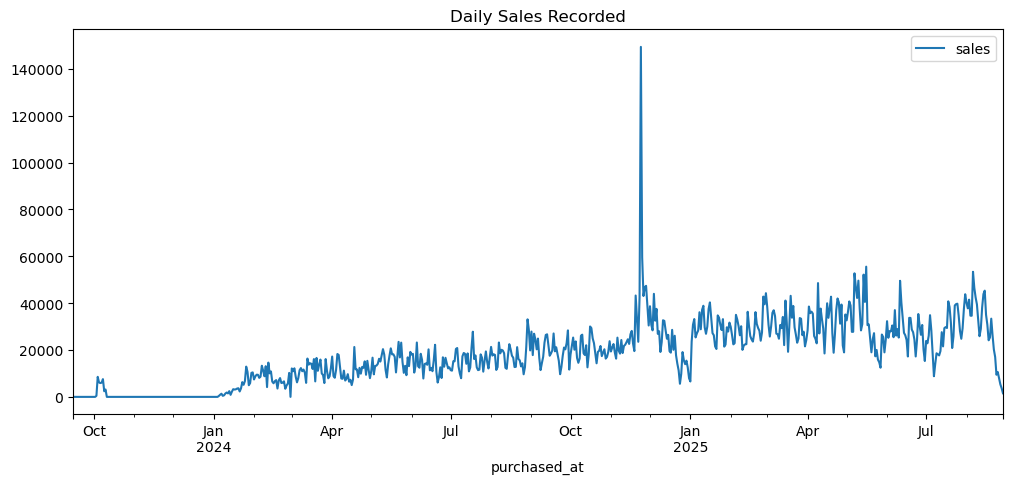

In [54]:
sales_df['sales'].plot(figsize=(12, 5))
plt.title(f'Daily Sales Recorded')
plt.legend()
plt.show()

- Dropping data for all the points from Oct 2023 to Jan 2024 as there isn't any recorded data.
- The day with Max Sales is 24th Nov 2024 - Black Friday (Outlier Event)
- There also appears a small trend and daily seasonality in sales.

#  Sales Time Series Analysis

## 1) Stationarity Testing

In [55]:
def is_stationary(series: pd.Series, sig_level=0.05) -> bool:
    '''
    Perform Augmented Dickey-Fuller test to check if the series is stationary.
    If p-value is less than the significance level, we reject the null hypothesis and infer that the series is stationary.
    '''
    result = adfuller(series)
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    return True if p_value < sig_level else False

Augmented Dickey-Fuller test to determine whether the time series is stationary or not.

In [56]:
print(f'Is Stationary: {is_stationary(sales_df["sales"])}')

ADF Statistic: -2.106862252491765
p-value: 0.2417642234856115
Is Stationary: False


The p-value > 0.05 (data is not stationary).

## 2) ETS Decomposition

ETS decomposes the sales series into three main components: trend, seasonality, and residuals.

In [57]:
decomposition = seasonal_decompose(sales_df['sales'], model='additive', period=7)

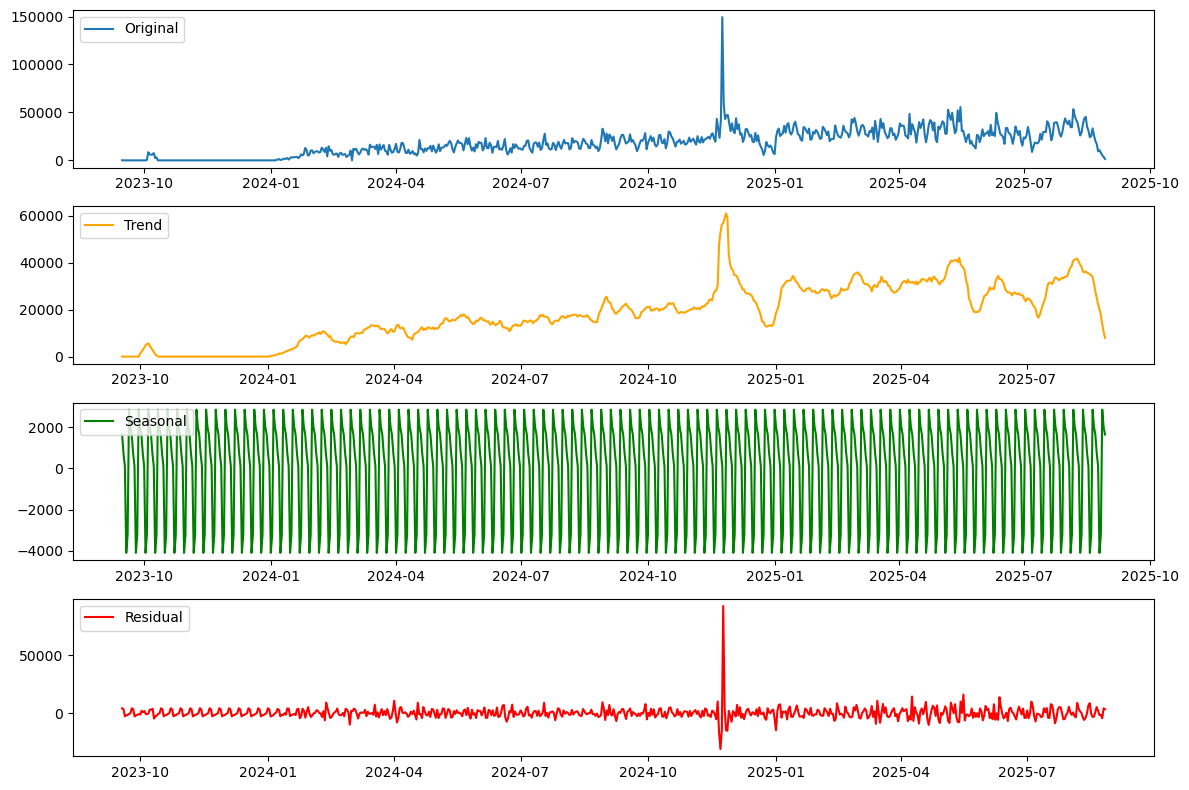

In [58]:
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(sales_df['sales'], label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

- There is a strong seasonality in the data. It is by every week.
- Trend is not strong but is present.
- there is a clear anomalous outlier around late 2024, visible in both the original series and the residual component.

<Axes: xlabel='purchased_at'>

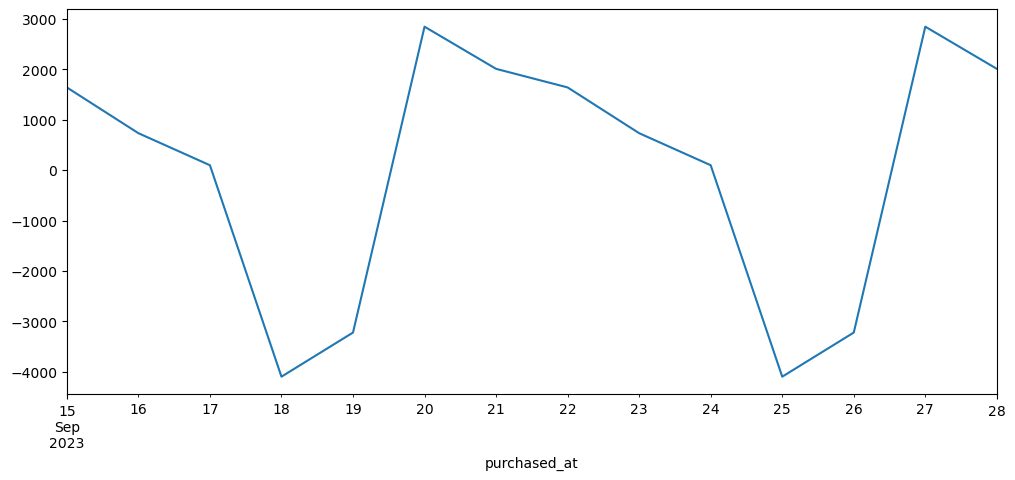

In [59]:
decomposition.seasonal[:14].plot(figsize=(12, 5))

Weekly seasonality is clearly observed, with a repeating 7-day pattern indicating day-of-week effects on sales.

## 3) ACF/PACF Analysis

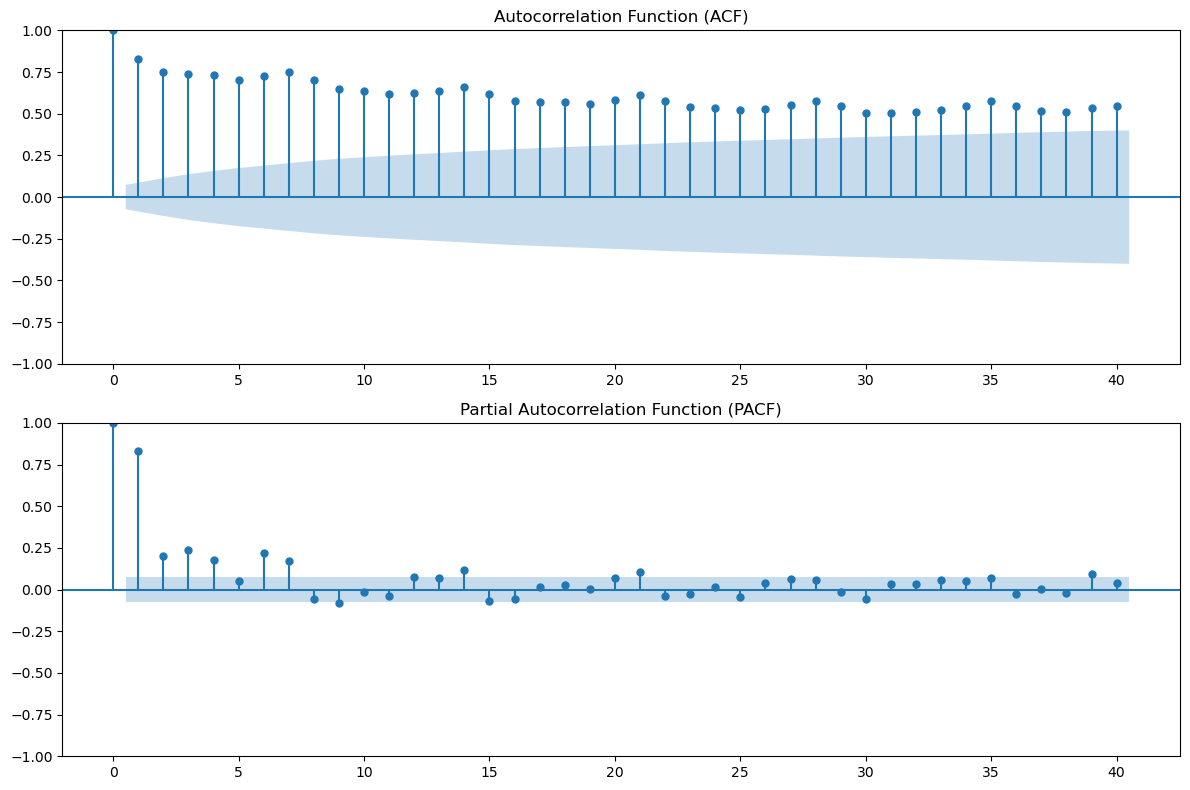

In [60]:
# Plot ACF and PACF
fig, ax = plt.subplots(2, figsize=(12, 8))

# Autocorrelation Function (ACF)
plot_acf(sales_df['sales'], lags=40, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF)')

# Partial Autocorrelation Function (PACF)
plot_pacf(sales_df['sales'], lags=40, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

- The ACF and PACF plots show how the sales series is correlated with its past values at different time lags.
- The ACF indicates strong persistence and possible seasonal behavior, while the PACF suggests that the first one or two lags are the most influential and may be sufficient as predictor variables.

## 4) Time Series Visualization

In [61]:
endog = sales_df['sales']
exog = sales_df[['is_holiday']]

<Axes: xlabel='purchased_at'>

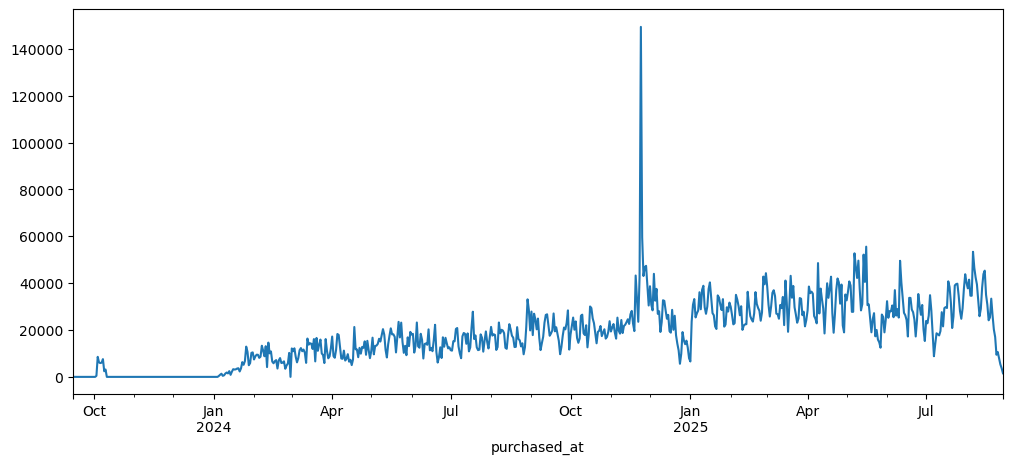

In [62]:
endog.plot(figsize=(12, 5))

# Sales Model Development and Forecasting

## 1) Train-test Split

In [63]:
train_size = int(len(endog) * 0.8)

# Data Split
endog_train, endog_test = endog[:train_size], endog[train_size:]
exog_train, exog_test = exog[:train_size], exog[train_size:]

Split the data into training and testing sets, using 80% for training the model and 20% for testing it.

endog_train and exog_train are the training data, while endog_test and exog_test are the testing data.

In [64]:
auto_model = auto_arima(endog_train,
                        exogenous=exog_train,
                        seasonal=True,
                        m=7,
                        trace=True,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True)

print(f'Optimal order: {auto_model.order}')
print(f'Optimal seasonal order: {auto_model.seasonal_order}')

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=11680.311, Time=1.64 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=11847.829, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=11785.550, Time=0.23 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=11710.107, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=11845.845, Time=0.03 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=11680.522, Time=1.23 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=inf, Time=1.93 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=inf, Time=4.20 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=11680.947, Time=2.81 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=11688.665, Time=0.44 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=11671.443, Time=2.97 sec
 ARIMA(1,1,2)(0,0,2)[7] intercept   : AIC=11678.957, Time=0.97 sec
 ARIMA(2,1,1)(0,0,2)[7] intercept   : AIC=11679.584, Time=1.05 sec
 ARIMA(3,1,2)(0,0,2)[7] intercept   : AIC=11678.467, Time=2.37 sec
 ARIMA(2,1,3)(0,0,2)[7] interce

Sse the training data to automatically find the best ARIMA model parameters, including the seasonal pattern, and then displays the selected order values.

## 2) SARIMAX Model

In [65]:
# Extract optimal parameters
p, d, q = auto_model.order
P, D, Q, s = auto_model.seasonal_order

# Fit the SARIMAX model
sarimax_model = SARIMAX(endog_train,
                        exog=exog_train,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=True,
                        enforce_invertibility=False).fit()

# Print the model summary
print(sarimax_model.summary())

C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                                      SARIMAX Results                                      
Dep. Variable:                               sales   No. Observations:                  572
Model:             SARIMAX(4, 1, 2)x(1, 0, [1], 7)   Log Likelihood               -5607.948
Date:                             Tue, 12 May 2026   AIC                          11235.895
Time:                                     10:37:23   BIC                          11279.369
Sample:                                 09-15-2023   HQIC                         11252.856
                                      - 04-08-2025                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_holiday    67.0988      0.742     90.385      0.000      65.644      68.554
ar.L1         -0.5127      

C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Forecast Generation

In [66]:
# Forecast
n_forecast = len(endog_test)
forecast = sarimax_model.get_forecast(steps=n_forecast, exog=exog_test)

# Get confidence intervals
conf_int = forecast.conf_int()

Fitted SARIMAX model generates forecasts using the test exogenous variables. Confidence intervals are extracted to show the range within which the predicted values are expected to fall with a certain level of confidence.

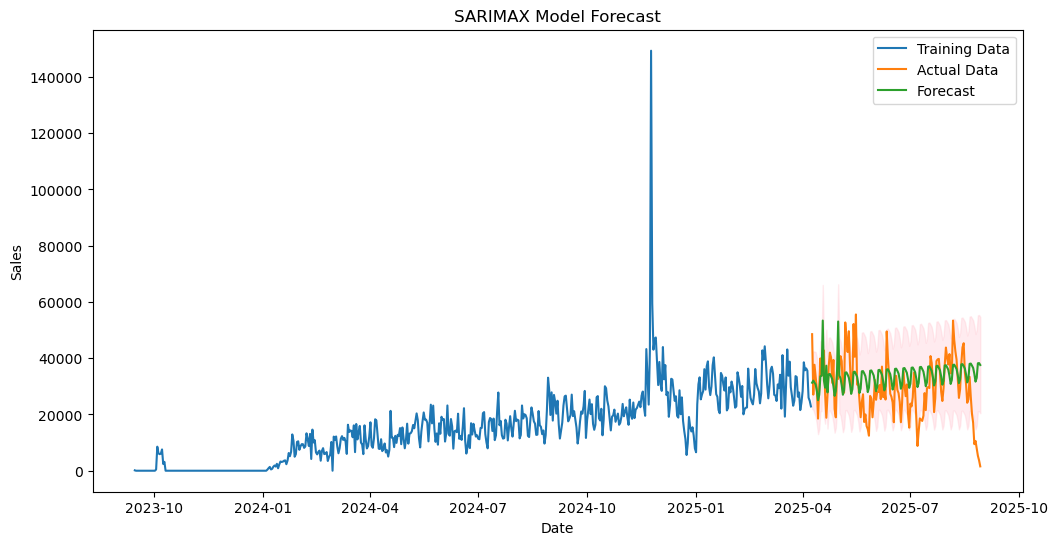

In [67]:
plt.figure(figsize=(12, 6))
plt.plot(endog_train.index, endog_train, label='Training Data')
plt.plot(endog_test.index, endog_test, label='Actual Data')
plt.plot(endog_test.index, forecast.predicted_mean, label='Forecast')
plt.fill_between(endog_test.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('SARIMAX Model Forecast')
plt.legend()
plt.show()

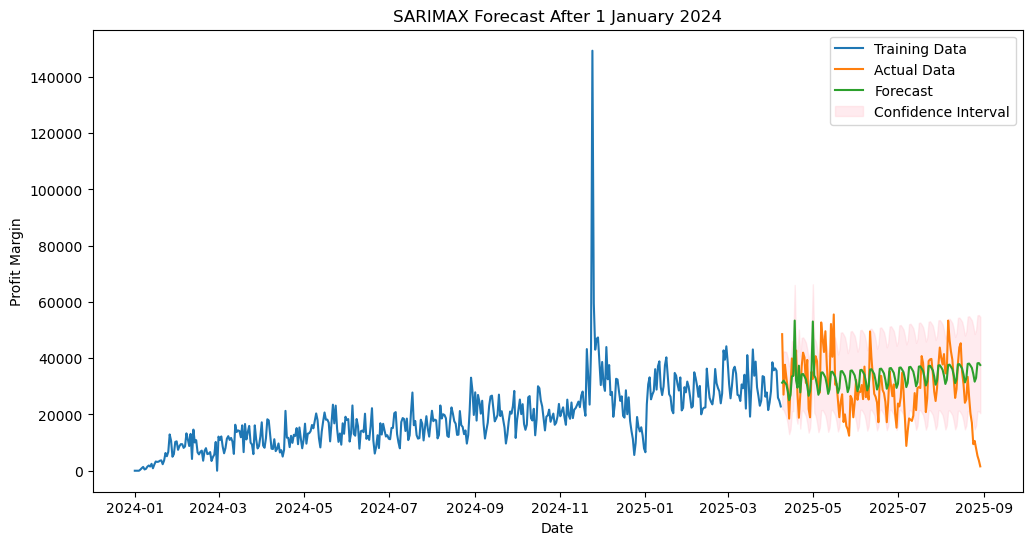

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

start_date = pd.Timestamp('2024-01-01')

train_series = endog_train[endog_train.index >= start_date]
test_series = endog_test[endog_test.index >= start_date]
forecast_mean = forecast.predicted_mean[forecast.predicted_mean.index >= start_date]
conf_int_filtered = conf_int.loc[conf_int.index >= start_date]

plt.figure(figsize=(12, 6))
plt.plot(train_series.index, train_series, label='Training Data')
plt.plot(test_series.index, test_series, label='Actual Data')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast')
plt.fill_between(
    conf_int_filtered.index,
    conf_int_filtered.iloc[:, 0],
    conf_int_filtered.iloc[:, 1],
    color='pink',
    alpha=0.3,
    label='Confidence Interval'
)

plt.xlabel('Date')
plt.ylabel('Profit Margin')
plt.title('SARIMAX Forecast After 1 January 2024')
plt.legend()
plt.show()

### Model Evaluation

In [69]:
mae = mean_absolute_error(endog_test, forecast.predicted_mean)
rmse = np.sqrt(mean_squared_error(endog_test, forecast.predicted_mean))

print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')

Mean Absolute Error: 8369.577143305629
Root Mean Squared Error: 10961.529601883107


In [70]:
print("Average sales:", endog.mean())
print("Median sales:", endog.median())
print("Minimum sales:", endog.min())
print("Maximum sales:", endog.max())

Average sales: 18252.827244755244
Median sales: 17785.66
Minimum sales: 0.0
Maximum sales: 149341.68


In [71]:
print("Average test sales:", endog_test.mean())
print("Median test sales:", endog_test.median())

Average test sales: 29686.967272727274
Median test sales: 29032.53


In [72]:
print((8369.577143305629 / endog_test.mean()) * 100)

28.192765756152415


In [73]:
mae = mean_absolute_error(endog_test, forecast.predicted_mean)
rmse = np.sqrt(mean_squared_error(endog_test, forecast.predicted_mean))

print("Average test sales:", endog_test.mean())
print("Median test sales:", endog_test.median())
print("MAE as % of average sales:", (mae / endog_test.mean()) * 100)
print("RMSE as % of average sales:", (rmse / endog_test.mean()) * 100)

Average test sales: 29686.967272727274
Median test sales: 29032.53
MAE as % of average sales: 28.192765756152415
RMSE as % of average sales: 36.92370965744692


## 3) XGBoost Model

### Feature Engineering

In [74]:
# Feature Engineering:

# Lag Features - AR part
sales_df['lag_1'] = sales_df['sales'].shift(1)
sales_df['lag_2'] = sales_df['sales'].shift(2)

# Rolling Statistics Features - MA part
sales_df['rolling_mean_2'] = sales_df['sales'].rolling(window=2).mean()

# Additional Features
sales_df['day_of_week'] = sales_df.index.dayofweek
sales_df['month'] = sales_df.index.month
sales_df['is_holiday'] = sales_df['is_holiday']

New input features from the original sales data to help the XGBoost model learn patterns more effectively.

The lag variables (lag_1 and lag_2) represent sales from previous periods, allowing the model to capture time dependence. The rolling mean feature summarizes recent sales behavior, which helps reflect short-term trends. In addition, the day_of_week, month, and is_holiday variables provide calendar and event-related information that may influence sales.

In [75]:
sales_features = sales_df.dropna()

In [76]:
X = sales_features[['lag_1', 'lag_2', 'rolling_mean_2', 'day_of_week', 'month', 'is_holiday']]
y = sales_features['sales']

### Train-test Split

In [77]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize and train the model
model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### Forecasting Generation

In [78]:
# Make predictions
y_pred = model.predict(X_test)

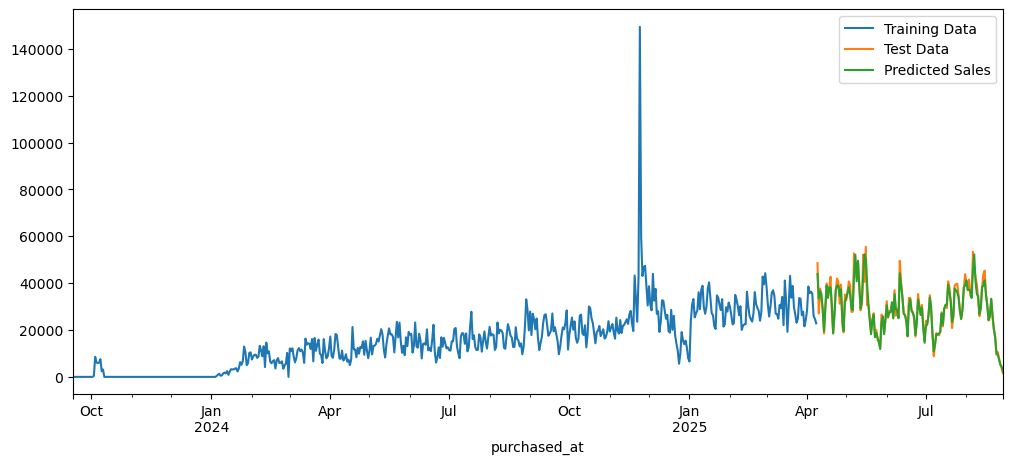

In [79]:
sales_df.loc[X_train.index]['sales'].plot(figsize=(12, 5), label='Training Data')
sales_df.loc[X_test.index]['sales'].plot(label='Test Data')
pd.Series(y_pred, index=y_test.index).plot(figsize=(12, 5), label='Predicted Sales')
plt.legend()
plt.show()

### Model Evaluation

In [80]:
# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

MAE: 1647.3004912177669
RMSE: 2612.5851053648867


In [81]:
print("Average sales:", endog.mean())
print("Median sales:", endog.median())
print("Minimum sales:", endog.min())
print("Maximum sales:", endog.max())

Average sales: 18252.827244755244
Median sales: 17785.66
Minimum sales: 0.0
Maximum sales: 149341.68


In [82]:
print("Average test sales:", endog_test.mean())
print("Median test sales:", endog_test.median())

Average test sales: 29686.967272727274
Median test sales: 29032.53


In [83]:
print((1647.3004912177669 / endog_test.mean()) * 100)

5.548901226873058


In [84]:
mae = mean_absolute_error(endog_test, forecast.predicted_mean)
rmse = np.sqrt(mean_squared_error(endog_test, forecast.predicted_mean))

print("Average test sales:", endog_test.mean())
print("Median test sales:", endog_test.median())
print("MAE as % of average sales:", (1647.3004912177669 / endog_test.mean()) * 100)
print("RMSE as % of average sales:", (2612.5851053648867 / endog_test.mean()) * 100)

Average test sales: 29686.967272727274
Median test sales: 29032.53
MAE as % of average sales: 5.548901226873058
RMSE as % of average sales: 8.800444590259673


# Profit Margin Time Series Preparation

In [85]:
profit_margin_df = df_data[['purchased_at', 'is_holiday', 'revenue', 'profit']].copy()

profit_margin_df.set_index('purchased_at', inplace=True)
profit_margin_df.sort_index(inplace=True)

# Aggregate to daily level
profit_margin_df = profit_margin_df.resample('D').agg({
    'revenue': 'sum',
    'profit': 'sum',
    'is_holiday': 'max'
})

# Compute weighted daily profit margin
profit_margin_df['profit_margin'] = np.where(
    profit_margin_df['revenue'] > 0,
    profit_margin_df['profit'] / profit_margin_df['revenue'],
    np.nan
)

profit_margin_df.dropna(inplace=True)

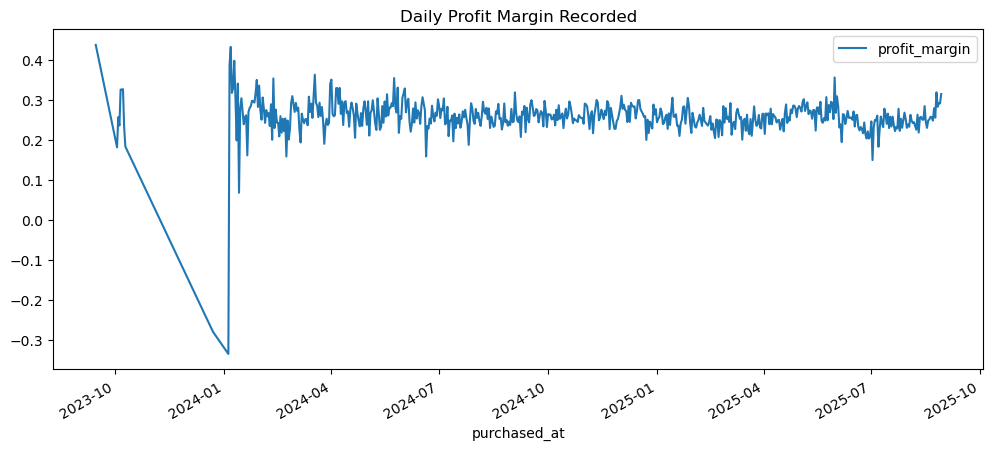

In [86]:
profit_margin_df['profit_margin'].plot(figsize=(12, 5))
plt.title('Daily Profit Margin Recorded')
plt.legend()
plt.show()

- Since the dataset does not contain an explicit quantity variable, each purchase line is treated as a single item-level transaction.
- Total cost is defined as `C = c + f`, where `c` is `unit_cost` and `f` is `delivery_fee`.
- Revenue is defined as `R = p`, where `p` is `selling_price`.
- Profit is computed as `R - C`.
- Profit margin is computed as `M = (R - C) / R`.
- For daily time-series modelling, daily revenue and daily profit are aggregated first, and the daily profit margin is then recomputed as `daily_profit / daily_revenue`, which preserves the same definition at the daily level.

# Profit Margin Time Series Analysis

## 1) Stationarity Testing

- Augmented Dickey-Fuller test to determine whether the profit margin time series is stationary or not.
- If the p-value is greater than 0.05, the profit margin series is not stationary and differencing may be required.

In [87]:
print(f'Is Stationary: {is_stationary(profit_margin_df["profit_margin"])}')

ADF Statistic: -3.810292716787116
p-value: 0.0028037452509499304
Is Stationary: True


## 2) ETS Decomposition

ETS decomposes the profit margin series into trend, seasonality, and residual components.

In [88]:
pm_decomposition = seasonal_decompose(profit_margin_df['profit_margin'], model='additive', period=7)

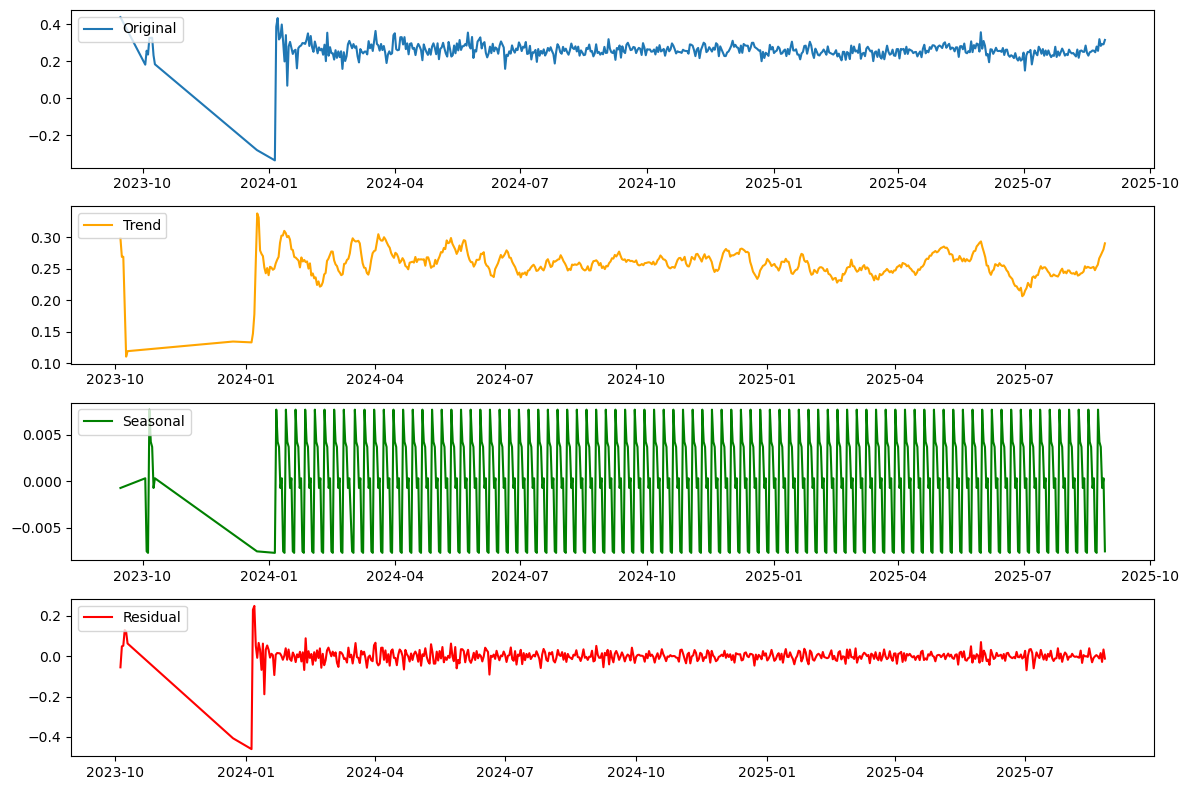

In [89]:
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(profit_margin_df['profit_margin'], label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(pm_decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(pm_decomposition.seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(pm_decomposition.resid, label='Residual', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

1. Original series
The profit margin series fluctuates mostly between 0.20 and 0.35 after early 2024, indicating a relatively stable level over time. The unusual movement at the beginning suggests possible initial irregularities or boundary effects.

2. Trend component
The trend remains fairly stable, mostly between 0.24 and 0.29, showing no strong long-term upward or downward movement. This indicates that the underlying profit margin level is generally consistent across the study period.

3. Seasonal component
The seasonal component shows a clear and repetitive pattern, indicating the presence of weekly seasonality in the profit margin series. Its small magnitude suggests that seasonality exists but has only a limited effect on overall variation.

4. Residual component
The residuals are centered around zero, which means most of the variation is explained by the trend and seasonal components. The remaining spikes may represent outliers or irregular business events such as promotions, delivery cost changes, or temporary anomalies.

In [90]:
pm_clean = profit_margin_df.loc['2024-01-01':].copy()

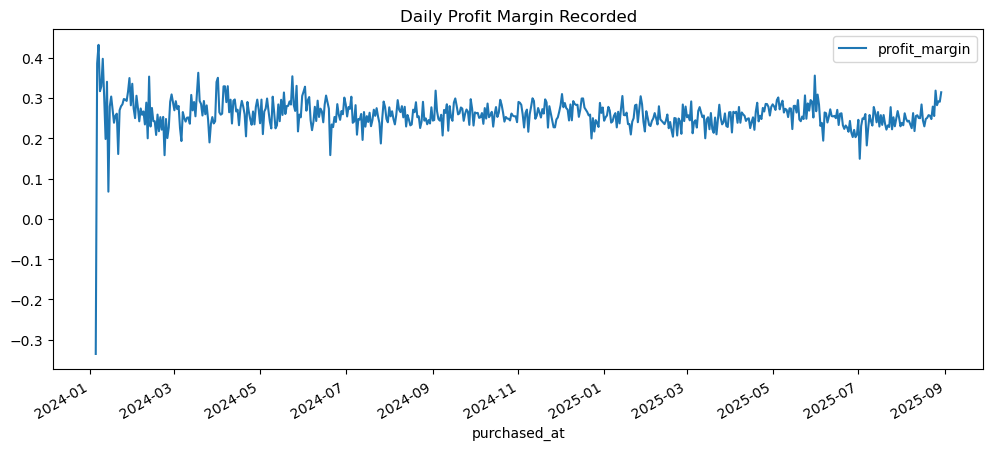

In [91]:
profit_margin_df.index = pd.to_datetime(profit_margin_df.index)
pm_clean = profit_margin_df.loc['2024-01-01':].copy()
pm_clean['profit_margin'].plot(figsize=(12, 5))
plt.title('Daily Profit Margin Recorded')
plt.legend()
plt.show()

In [92]:
from statsmodels.tsa.seasonal import seasonal_decompose

pm_decomposition = seasonal_decompose(
    pm_clean['profit_margin'],
    model='additive',
    period=7
)

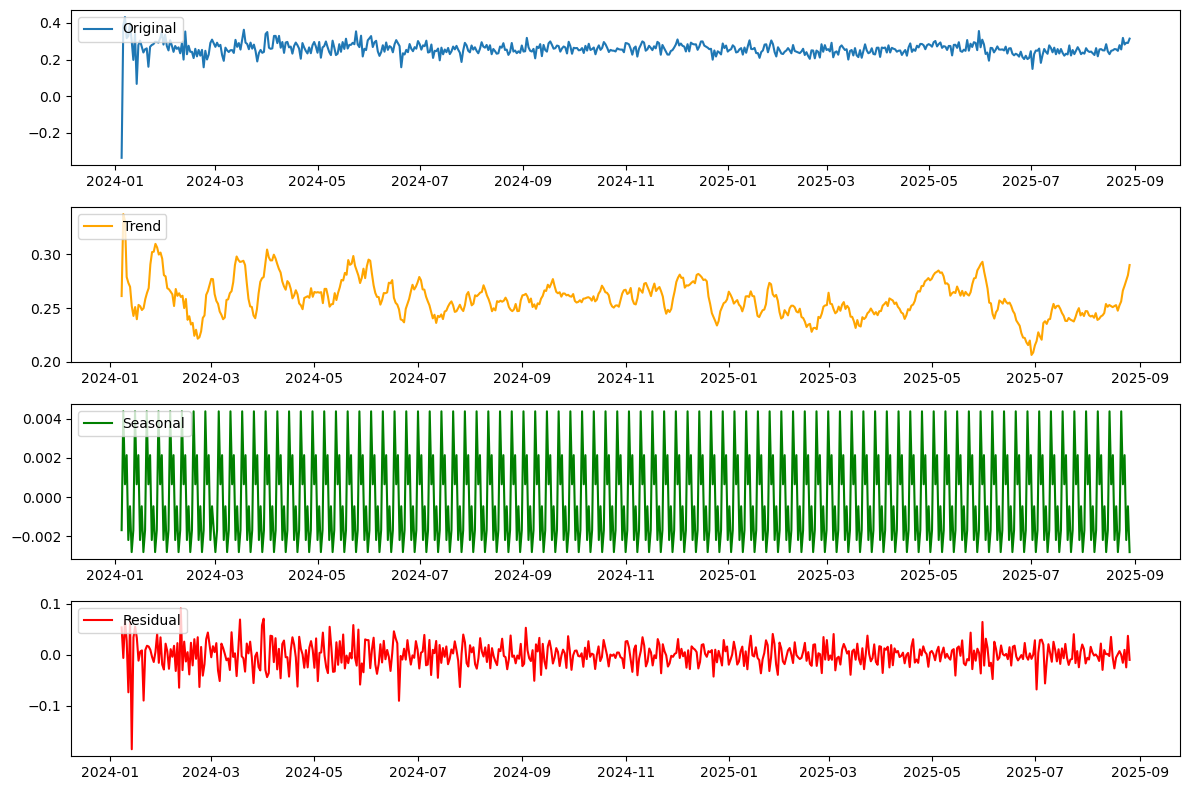

In [93]:
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(pm_clean['profit_margin'], label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(pm_decomposition.trend, label='Trend', color='orange')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(pm_decomposition.seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(pm_decomposition.resid, label='Residual', color='red')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

## 3) ACF/PACF Analysis

The ACF and PACF plots show how the profit margin series depends on previous days.

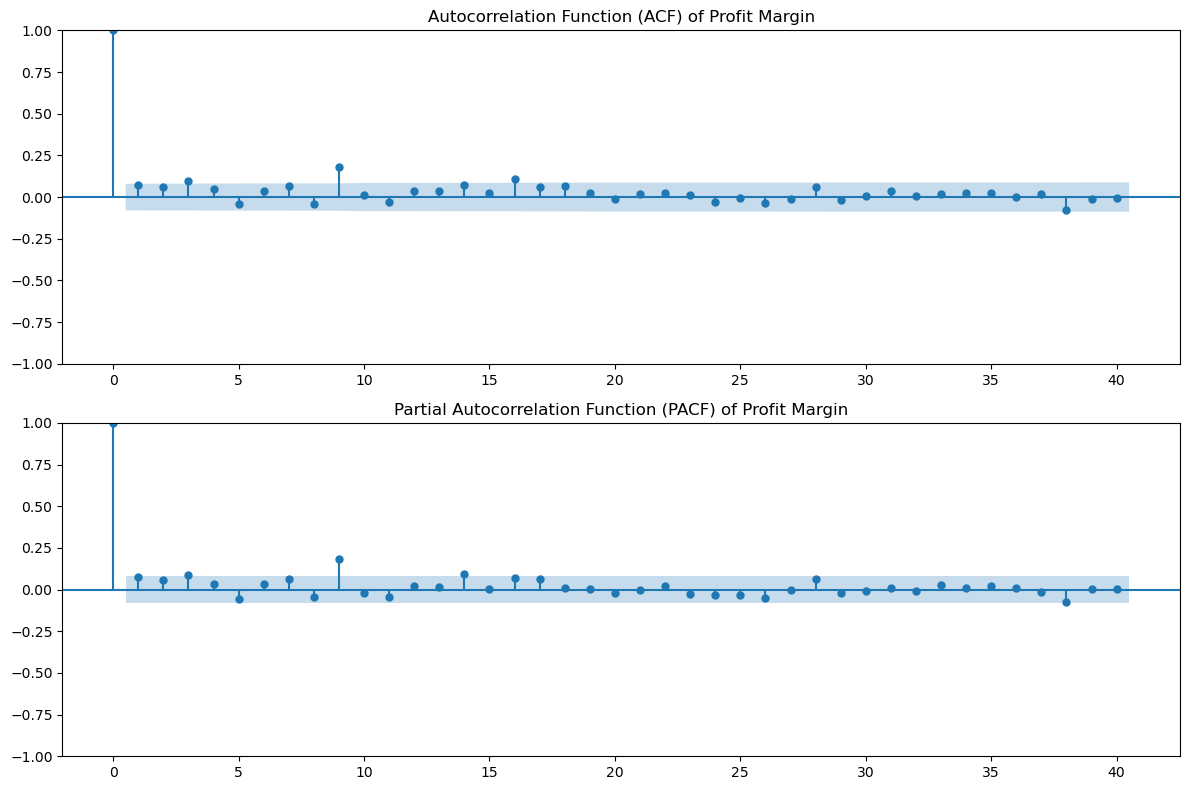

In [94]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Remove the unstable beginning of the series
pm_clean = profit_margin_df.loc['2024-01-01':, 'profit_margin'].dropna()

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(pm_clean, lags=40, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF) of Profit Margin')

plot_pacf(pm_clean, lags=40, ax=ax[1], method='ywm')
ax[1].set_title('Partial Autocorrelation Function (PACF) of Profit Margin')

plt.tight_layout()
plt.show()

The corrected ACF and PACF plots show that most autocorrelations are weak and remain close to zero, indicating limited serial dependence in the profit margin series. A small significant spike appears around lag 9, but the overall pattern does not suggest strong autoregressive or seasonal behavior.

## 4) Profit Margin Time Series Visualizations

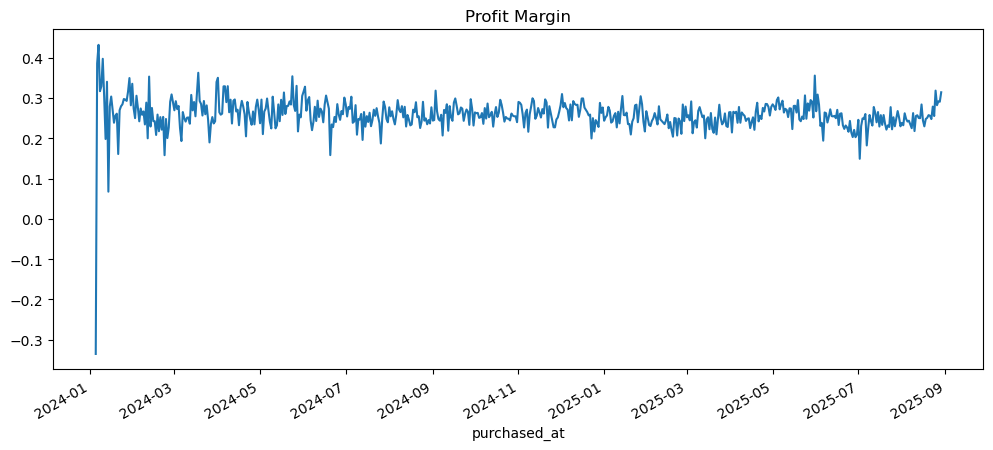

In [95]:
pm_data = profit_margin_df.loc[profit_margin_df.index >= '2024-01-01'].copy()

pm_endog = pm_data['profit_margin']
pm_exog = pm_data[['is_holiday']]

pm_endog.plot(figsize=(12, 5), title='Profit Margin')
plt.show()

# Profit Margin Hybrid Model Development and Forecasting

This section implements the **sequential hybrid forecasting framework** described in the abstract.  
First, **SARIMAX** is used to model the linear structure of daily profit margin, including trend, weekly seasonality, and the effect of exogenous calendar variables such as holidays.  
Second, the **residuals from the SARIMAX model** are passed to **XGBoost** so that the machine-learning stage can learn the nonlinear patterns that remain unexplained by the time-series model.


## 1) Train-test Split


In [96]:
pm_train_size = int(len(pm_endog) * 0.8)

pm_endog_train, pm_endog_test = pm_endog[:pm_train_size], pm_endog[pm_train_size:]
pm_exog_train, pm_exog_test = pm_exog[:pm_train_size], pm_exog[pm_train_size:]

The profit margin time series and its exogenous variables are divided into training and testing sets using an 80/20 split.  
The training set is used to estimate the SARIMAX model and train the residual learner, while the test set is used to evaluate out-of-sample forecasting performance.


### SARIMAX Order Selection

The training data are used to identify suitable SARIMAX orders automatically.  
This step supports the model specification process by selecting the non-seasonal and seasonal parameters that best capture the temporal structure of the profit margin series, including the weekly seasonal pattern.


In [97]:
pm_auto_model_noexog = auto_arima(
    pm_endog_train,
    seasonal=True,
    m=7,
    test='adf',
    seasonal_test='ocsb',
    d=None,
    D=None,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=False,
    information_criterion='aic'
)

print("No-exog order:", pm_auto_model_noexog.order)
print("No-exog seasonal order:", pm_auto_model_noexog.seasonal_order)

 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=-1672.842, Time=0.10 sec
 ARIMA(0,0,0)(0,0,1)[7] intercept   : AIC=-1672.018, Time=0.25 sec
 ARIMA(0,0,0)(0,0,2)[7] intercept   : AIC=-1672.111, Time=0.42 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=-1672.237, Time=1.45 sec
 ARIMA(0,0,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.91 sec
 ARIMA(0,0,0)(1,0,2)[7] intercept   : AIC=-1641.477, Time=2.45 sec
 ARIMA(0,0,0)(2,0,0)[7] intercept   : AIC=inf, Time=3.89 sec
 ARIMA(0,0,0)(2,0,1)[7] intercept   : AIC=-1351.055, Time=1.01 sec
 ARIMA(0,0,0)(2,0,2)[7] intercept   : AIC=inf, Time=2.62 sec
 ARIMA(0,0,1)(0,0,0)[7] intercept   : AIC=-1671.950, Time=0.37 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=-1671.335, Time=0.49 sec
 ARIMA(0,0,1)(0,0,2)[7] intercept   : AIC=-1671.470, Time=1.57 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=-1671.598, Time=1.23 sec
 ARIMA(0,0,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.96 sec
 ARIMA(0,0,1)(1,0,2)[7] intercept   : AIC=-1644.629, Time=2.63 sec
 ARIMA(0,0,1)(2,0,0

### Manual SARIMAX candidate comparison

In [98]:
candidate_orders = [
    
    ((1, 1, 1), (1, 0, 1, 7)),
    ((2, 1, 1), (1, 0, 1, 7)),
    ((2, 1, 3), (1, 0, 1, 7)),
]

candidate_results = []

for order, seasonal_order in candidate_orders:
    try:
        model = SARIMAX(
            pm_endog_train,
            exog=pm_exog_train,
            order=order,
            seasonal_order=seasonal_order,
            trend='c',
            enforce_stationarity=True,
            enforce_invertibility=False
        ).fit(disp=False)

        candidate_results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": model.aic,
            "bic": model.bic
        })
    except Exception as e:
        candidate_results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": None,
            "bic": None
        })

candidate_results

C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forec

[{'order': (1, 1, 1),
  'seasonal_order': (1, 0, 1, 7),
  'aic': np.float64(-1639.24111868922),
  'bic': np.float64(-1610.0246159619064)},
 {'order': (2, 1, 1),
  'seasonal_order': (1, 0, 1, 7),
  'aic': np.float64(-1653.01475676079),
  'bic': np.float64(-1619.6244679295746)},
 {'order': (2, 1, 3),
  'seasonal_order': (1, 0, 1, 7),
  'aic': np.float64(-1652.272613938797),
  'bic': np.float64(-1610.5347528997775)}]

In [99]:
import pandas as pd

candidate_df = pd.DataFrame(candidate_results).sort_values("aic", ascending=True)
candidate_df

,order,seasonal_order,aic,bic
1,"(2, 1, 1)","(1, 0, 1, 7)",-1653.014757,-1619.624468
2,"(2, 1, 3)","(1, 0, 1, 7)",-1652.272614,-1610.534753
0,"(1, 1, 1)","(1, 0, 1, 7)",-1639.241119,-1610.024616


In [100]:
pm_sarimax_model = SARIMAX(
    pm_endog_train,
    exog=pm_exog_train,
    order=(2, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    trend='c',
    enforce_stationarity=True,
    enforce_invertibility=False
).fit(disp=False)

print(pm_sarimax_model.summary())
print("AIC:", pm_sarimax_model.aic)
print("BIC:", pm_sarimax_model.bic)

C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                     profit_margin   No. Observations:                  481
Model:             SARIMAX(2, 1, 1)x(1, 0, 1, 7)   Log Likelihood                 834.507
Date:                           Tue, 12 May 2026   AIC                          -1653.015
Time:                                   10:40:17   BIC                          -1619.624
Sample:                                        0   HQIC                         -1639.890
                                           - 481                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -4.109e-05    4.9e-05     -0.839      0.401      -0.000    5.49e-05
is_holiday    -0.0087      0.019     -0.456

In [101]:
pm_forecast = pm_sarimax_model.get_forecast(
    steps=len(pm_endog_test),
    exog=pm_exog_test
)

pm_pred_mean = pm_forecast.predicted_mean
pm_conf_int = pm_forecast.conf_int()

C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## 2) SARIMAX Baseline Model


In [102]:
# Reuse the selected SARIMAX specification from the candidate comparison above.
# The final benchmark model is the manually selected SARIMAX(2,1,1)(1,0,1,7),
# already fitted in the previous step as `pm_sarimax_model`.

print("Using selected SARIMAX benchmark:")
print("Order: (2, 1, 1)")
print("Seasonal order: (1, 0, 1, 7)")

Using selected SARIMAX benchmark:
Order: (2, 1, 1)
Seasonal order: (1, 0, 1, 7)


### Baseline Forecast Generation


In [103]:
pm_n_forecast = len(pm_endog_test)
pm_forecast = pm_sarimax_model.get_forecast(steps=pm_n_forecast, exog=pm_exog_test)

pm_conf_int = pm_forecast.conf_int()

C:\Users\MostafaSalem\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


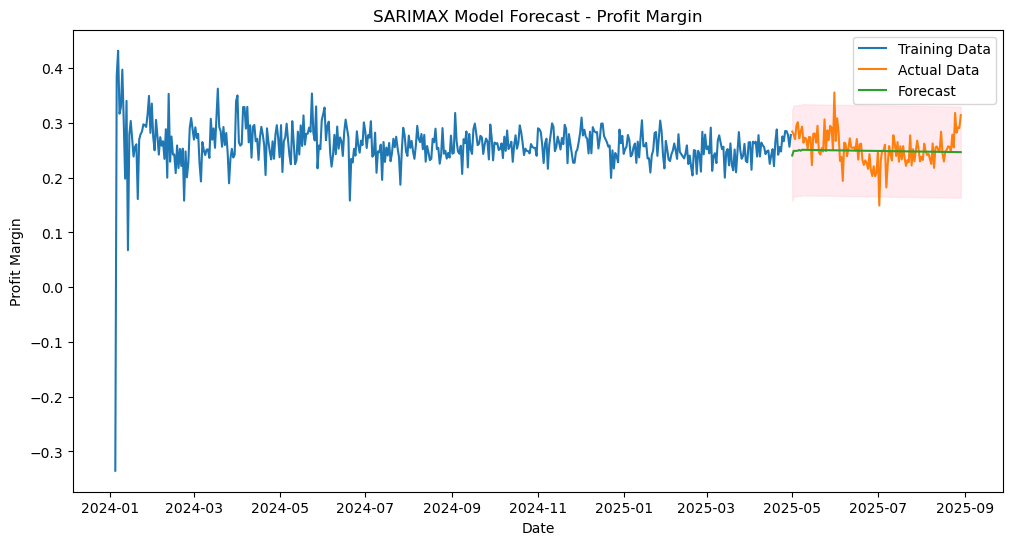

In [104]:
plt.figure(figsize=(12, 6))
plt.plot(pm_endog_train.index, pm_endog_train, label='Training Data')
plt.plot(pm_endog_test.index, pm_endog_test, label='Actual Data')
plt.plot(pm_endog_test.index, pm_forecast.predicted_mean, label='Forecast')
plt.fill_between(pm_endog_test.index,
                 pm_conf_int.iloc[:, 0],
                 pm_conf_int.iloc[:, 1], color='pink', alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Profit Margin')
plt.title('SARIMAX Model Forecast - Profit Margin')
plt.legend()
plt.show()

The SARIMAX model serves as the **baseline forecasting component**.  
It captures the main linear and seasonal structure of the profit margin series, but any remaining unexplained variation is retained in the model residuals for the second stage of the hybrid framework.


### Baseline Model Evaluation


In [105]:
pm_mae = mean_absolute_error(pm_endog_test, pm_forecast.predicted_mean)
pm_rmse = np.sqrt(mean_squared_error(pm_endog_test, pm_forecast.predicted_mean))

print(f'Mean Absolute Error: {pm_mae}')
print(f'Root Mean Squared Error: {pm_rmse}')

Mean Absolute Error: 0.021743586434538213
Root Mean Squared Error: 0.02902319139382647


In [106]:
print("Average profit margin:", pm_endog.mean())
print("Median profit margin:", pm_endog.median())
print("Minimum profit margin:", pm_endog.min())
print("Maximum profit margin:", pm_endog.max())

Average profit margin: 0.2585772797055192
Median profit margin: 0.257712815186235
Minimum profit margin: -0.3352229780801209
Maximum profit margin: 0.4318514683038686


In [107]:
print("Average test profit margin:", pm_endog_test.mean())
print("Median test profit margin:", pm_endog_test.median())
print("MAE as % of average test profit margin:", (pm_mae / pm_endog_test.mean()) * 100)
print("RMSE as % of average test profit margin:", (pm_rmse / pm_endog_test.mean()) * 100)

Average test profit margin: 0.25378251555295545
Median test profit margin: 0.2525342568359461
MAE as % of average test profit margin: 8.567803178702867
RMSE as % of average test profit margin: 11.436245452366618


## 3) Sequential Hybrid Model: SARIMAX Residuals -> XGBoost


### Residual Feature Engineering

After fitting SARIMAX, the in-sample residuals are calculated as the difference between the observed profit margin and the SARIMAX fitted values.  
These residuals represent the part of the series that is **not explained by the linear seasonal model**.  
Lagged residual values and calendar-based features are then constructed so that XGBoost can learn nonlinear dependencies and irregular fluctuations.


In [108]:
# Build a residual learning dataset from the SARIMAX component
pm_train_pred = pd.Series(pm_sarimax_model.fittedvalues, index=pm_endog_train.index)
pm_test_pred = pd.Series(pm_forecast.predicted_mean, index=pm_endog_test.index)

pm_train_residuals = pm_endog_train - pm_train_pred
pm_test_residuals = pm_endog_test - pm_test_pred

pm_hybrid_df = pd.DataFrame(index=pm_endog.index)
pm_hybrid_df['profit_margin'] = pm_endog
pm_hybrid_df['sarimax_pred'] = pd.concat([pm_train_pred, pm_test_pred]).sort_index()
pm_hybrid_df['sarimax_residual'] = pm_hybrid_df['profit_margin'] - pm_hybrid_df['sarimax_pred']
pm_hybrid_df['is_holiday'] = pm_exog['is_holiday']
pm_hybrid_df['day_of_week'] = pm_hybrid_df.index.dayofweek
pm_hybrid_df['month'] = pm_hybrid_df.index.month

# Residual lags and rolling statistics are used so XGBoost learns unexplained nonlinear patterns
pm_hybrid_df['residual_lag_1'] = pm_hybrid_df['sarimax_residual'].shift(1)
pm_hybrid_df['residual_lag_2'] = pm_hybrid_df['sarimax_residual'].shift(2)
pm_hybrid_df['residual_lag_7'] = pm_hybrid_df['sarimax_residual'].shift(7)
pm_hybrid_df['residual_roll_mean_3'] = pm_hybrid_df['sarimax_residual'].shift(1).rolling(window=3).mean()
pm_hybrid_df['residual_roll_std_3'] = pm_hybrid_df['sarimax_residual'].shift(1).rolling(window=3).std()


The XGBoost stage does **not** predict the original profit margin directly.  
Instead, it predicts the **SARIMAX residual component**, which makes the workflow consistent with the abstract:  
1. model linear temporal structure with SARIMAX,  
2. learn nonlinear residual behavior with XGBoost, and  
3. combine both parts into a final hybrid forecast.


In [109]:
pm_hybrid_features = pm_hybrid_df.dropna().copy()

pm_feature_cols = [
    'sarimax_pred',
    'residual_lag_1',
    'residual_lag_2',
    'residual_lag_7',
    'residual_roll_mean_3',
    'residual_roll_std_3',
    'day_of_week',
    'month',
    'is_holiday'
]

# Split the hybrid dataset using the same temporal test start as SARIMAX.
# If lag/rolling operations remove all rows in the intended test window,
# fall back to a final 20% holdout so evaluation remains possible.
pm_test_start = pm_endog_test.index.min()
pm_train_hybrid = pm_hybrid_features.loc[pm_hybrid_features.index < pm_test_start].copy()
pm_test_hybrid = pm_hybrid_features.loc[pm_hybrid_features.index >= pm_test_start].copy()

if len(pm_test_hybrid) == 0:
    pm_hybrid_train_size = int(len(pm_hybrid_features) * 0.8)
    pm_train_hybrid = pm_hybrid_features.iloc[:pm_hybrid_train_size].copy()
    pm_test_hybrid = pm_hybrid_features.iloc[pm_hybrid_train_size:].copy()
    print('Hybrid split fallback applied: using final 20% of hybrid features as test set.')

print('Hybrid feature rows:', len(pm_hybrid_features))
print('Hybrid train rows:', len(pm_train_hybrid))
print('Hybrid test rows:', len(pm_test_hybrid))
if len(pm_test_hybrid) > 0:
    print('Hybrid test window:', pm_test_hybrid.index.min(), 'to', pm_test_hybrid.index.max())



Hybrid split fallback applied: using final 20% of hybrid features as test set.
Hybrid feature rows: 474
Hybrid train rows: 379
Hybrid test rows: 95
Hybrid test window: 2025-01-26 00:00:00 to 2025-04-30 00:00:00


In [110]:
pm_X_train = pm_train_hybrid[pm_feature_cols]
pm_y_train = pm_train_hybrid['sarimax_residual']

pm_X_test = pm_test_hybrid[pm_feature_cols]
pm_y_test = pm_test_hybrid['sarimax_residual']

print('pm_X_train shape:', pm_X_train.shape)
print('pm_X_test shape:', pm_X_test.shape)



pm_X_train shape: (379, 9)
pm_X_test shape: (95, 9)


### Train the Residual Learner

XGBoost is trained on the engineered residual dataset.  
Its role is to estimate the nonlinear correction term that will later be added to the SARIMAX baseline forecast.


In [111]:
pm_xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
pm_xgb_model.fit(pm_X_train, pm_y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

### Hybrid Forecast Generation

For the test period, XGBoost predicts the expected residual correction.  
The final hybrid forecast is then obtained as:

**Hybrid forecast = SARIMAX forecast + predicted residual correction**

This preserves the interpretability of the SARIMAX component while improving accuracy through nonlinear residual learning.


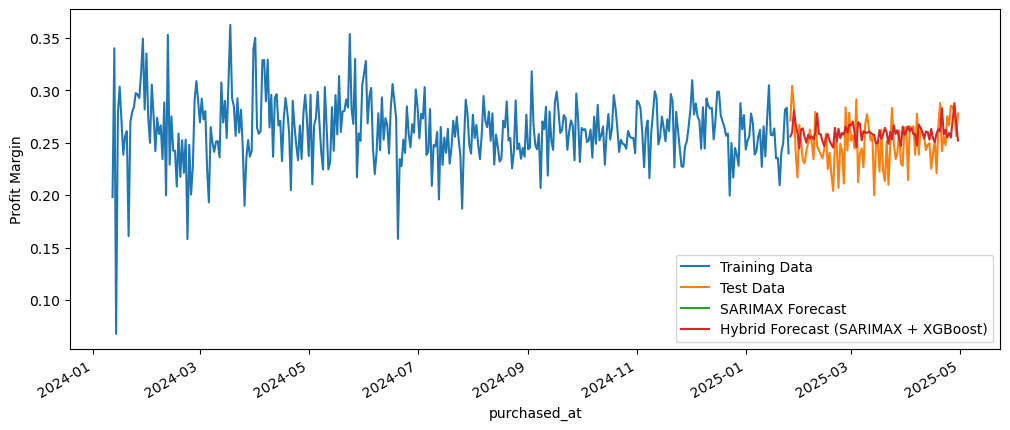

In [112]:
# Predict residual corrections, then add them back to the SARIMAX forecast
pm_residual_pred = pd.Series(pm_xgb_model.predict(pm_X_test), index=pm_X_test.index)
pm_hybrid_forecast = pm_test_hybrid['sarimax_pred'] + pm_residual_pred
pm_hybrid_actual = pm_test_hybrid['profit_margin']

# Align the baseline SARIMAX forecast to the hybrid test window for plotting/comparison
pm_sarimax_baseline_aligned = pm_test_pred.reindex(pm_hybrid_actual.index)

pm_plot_df = profit_margin_df.loc['2024-01-01':].copy()
plot_train_idx = pm_train_hybrid.index.intersection(pm_plot_df.index)
plot_test_idx = pm_hybrid_actual.index.intersection(pm_plot_df.index)

plt.figure(figsize=(12, 5))
pm_plot_df.loc[plot_train_idx, 'profit_margin'].plot(label='Training Data')
pm_plot_df.loc[plot_test_idx, 'profit_margin'].plot(label='Test Data')
pm_sarimax_baseline_aligned.loc[plot_test_idx].plot(label='SARIMAX Forecast')
pm_hybrid_forecast.loc[plot_test_idx].plot(label='Hybrid Forecast (SARIMAX + XGBoost)')
plt.xlabel('purchased_at')
plt.ylabel('Profit Margin')
plt.legend()
plt.show()



### Hybrid Model Evaluation

The hybrid model is evaluated against the test set and compared with the standalone SARIMAX baseline.  
This comparison shows whether learning the residual structure with XGBoost improves forecasting performance for daily profit margin.


In [113]:
print("pm_y_test:", len(pm_y_test))
print("pm_residual_pred:", len(pm_residual_pred))
print("pm_hybrid_actual:", len(pm_hybrid_actual))
print("pm_hybrid_forecast:", len(pm_hybrid_forecast))
print("pm_endog_test:", len(pm_endog_test))
print("pm_test_pred:", len(pm_test_pred))

pm_y_test: 95
pm_residual_pred: 95
pm_hybrid_actual: 95
pm_hybrid_forecast: 95
pm_endog_test: 121
pm_test_pred: 121


In [114]:

# Residual learner evaluation
# --------------------------------------------------
pm_residual_eval = pd.DataFrame({
    'actual_residual': np.array(pm_y_test),
    'pred_residual': np.array(pm_residual_pred)
}).dropna()

if len(pm_residual_eval) > 0:
    pm_xgb_mae = mean_absolute_error(
        pm_residual_eval['actual_residual'],
        pm_residual_eval['pred_residual']
    )
    pm_xgb_rmse = np.sqrt(mean_squared_error(
        pm_residual_eval['actual_residual'],
        pm_residual_eval['pred_residual']
    ))
else:
    pm_xgb_mae = np.nan
    pm_xgb_rmse = np.nan


# --------------------------------------------------
# Final hybrid forecast evaluation
# --------------------------------------------------
pm_hybrid_eval = pd.DataFrame({
    'actual': np.array(pm_hybrid_actual),
    'forecast': np.array(pm_hybrid_forecast)
}).dropna()

if len(pm_hybrid_eval) > 0:
    pm_hybrid_mae = mean_absolute_error(
        pm_hybrid_eval['actual'],
        pm_hybrid_eval['forecast']
    )
    pm_hybrid_rmse = np.sqrt(mean_squared_error(
        pm_hybrid_eval['actual'],
        pm_hybrid_eval['forecast']
    ))
else:
    pm_hybrid_mae = np.nan
    pm_hybrid_rmse = np.nan


# --------------------------------------------------
# Print results
# --------------------------------------------------
print('Residual learner performance (XGBoost on SARIMAX residuals)')
if pd.notna(pm_xgb_mae):
    print(f'MAE: {pm_xgb_mae:.4f}')
    print(f'RMSE: {pm_xgb_rmse:.4f}')
else:
    print('MAE: not available (empty residual test set)')
    print('RMSE: not available (empty residual test set)')

print()
print('Final hybrid forecasting performance')
if pd.notna(pm_hybrid_mae):
    print(f'MAE: {pm_hybrid_mae:.4f}')
    print(f'RMSE: {pm_hybrid_rmse:.4f}')

    # Safe aligned SARIMAX baseline comparison
    common_index = pm_endog_test.index.intersection(pm_test_pred.index)

    # If hybrid actual has an index, align to the same hybrid window too
    if hasattr(pm_hybrid_actual, 'index'):
        common_index = common_index.intersection(pm_hybrid_actual.index)

    if len(common_index) > 0:
        aligned_baseline = pm_endog_test.loc[common_index]
        aligned_forecast = pm_test_pred.loc[common_index]

        pm_baseline_rmse_aligned = np.sqrt(
            mean_squared_error(aligned_baseline, aligned_forecast)
        )

        print(f'SARIMAX RMSE baseline (aligned window): {pm_baseline_rmse_aligned:.4f}')
        print(f'RMSE improvement over SARIMAX: {(1 - pm_hybrid_rmse / pm_baseline_rmse_aligned) * 100:.2f}%')
    else:
        print('SARIMAX RMSE baseline (aligned window): not available')
        print('RMSE improvement over SARIMAX: not available (no overlapping baseline window)')
else:
    print('MAE: not available (empty hybrid evaluation set)')
    print('RMSE: not available (empty hybrid evaluation set)')
    print(f'SARIMAX RMSE baseline: {pm_rmse:.4f}')
    print('RMSE improvement over SARIMAX: not available')

Residual learner performance (XGBoost on SARIMAX residuals)
MAE: 0.0194
RMSE: 0.0245

Final hybrid forecasting performance
MAE: 0.0194
RMSE: 0.0245
SARIMAX RMSE baseline (aligned window): not available
RMSE improvement over SARIMAX: not available (no overlapping baseline window)


In [115]:
print("Average profit margin:", pm_endog.mean())
print("Median profit margin:", pm_endog.median())
print("Minimum profit margin:", pm_endog.min())
print("Maximum profit margin:", pm_endog.max())

Average profit margin: 0.2585772797055192
Median profit margin: 0.257712815186235
Minimum profit margin: -0.3352229780801209
Maximum profit margin: 0.4318514683038686


In [116]:
print("Average profit margin:", pm_hybrid_actual.mean())
print("Median profit margin:", pm_hybrid_actual.median())
print("Hybrid MAE as % of average test profit margin:", (pm_hybrid_mae / pm_hybrid_actual.mean()) * 100)


Average profit margin: 0.24955304333514952
Median profit margin: 0.24952796601355295
Hybrid MAE as % of average test profit margin: 7.755047571168568


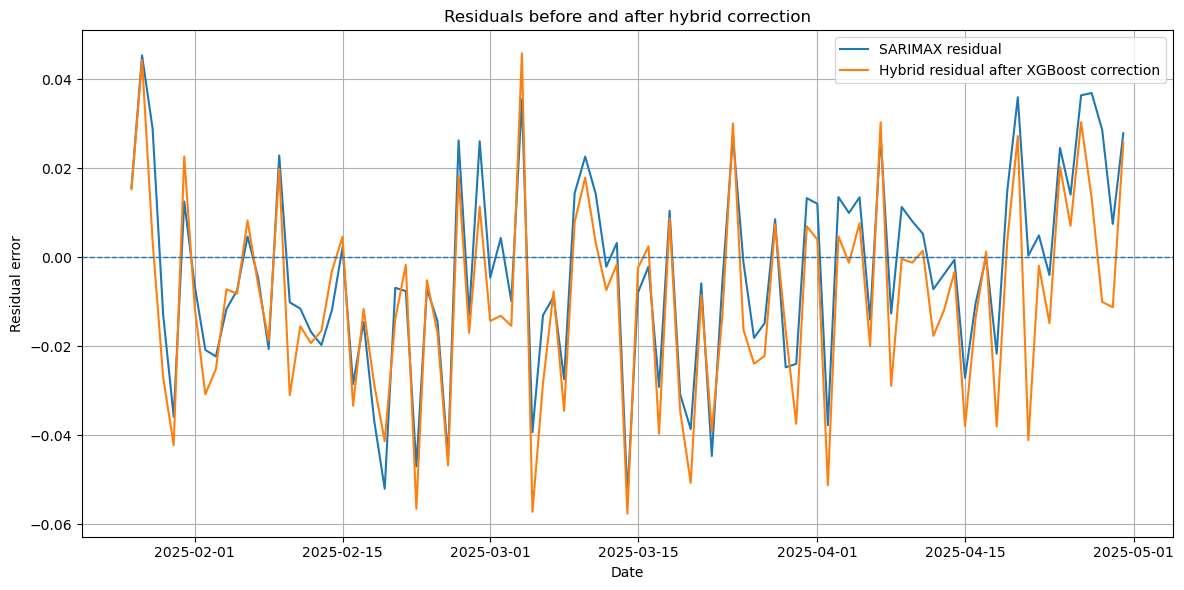

In [117]:
# Residuals before and after hybrid correction

pm_residual_comparison = pd.DataFrame({
    'SARIMAX residual': pm_test_hybrid['sarimax_residual'],
    'Hybrid residual after correction': pm_hybrid_actual - pm_hybrid_forecast
}).dropna()

plt.figure(figsize=(12, 6))
plt.plot(
    pm_residual_comparison.index,
    pm_residual_comparison['SARIMAX residual'],
    label='SARIMAX residual'
)

plt.plot(
    pm_residual_comparison.index,
    pm_residual_comparison['Hybrid residual after correction'],
    label='Hybrid residual after XGBoost correction'
)

plt.axhline(0, linestyle='--', linewidth=1)
plt.title('Residuals before and after hybrid correction')
plt.xlabel('Date')
plt.ylabel('Residual error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Demand Forecasting across Product Categories

## Phase 1 — Prepare category-level demand data

In [118]:
# Phase 1: Prepare data

x = df_data[['purchased_at', 'category_name', 'is_holiday', 'line_id']].copy()

# Create a date-only column from purchased_at
x['purchased_date'] = pd.to_datetime(x['purchased_at']).dt.normalize()

# Rename category_name for consistency with forecasting code
x = x.rename(columns={'category_name': 'product_category'})

x.head()

,purchased_at,product_category,is_holiday,line_id,purchased_date
0,2024-10-02 10:56:00,housewares,0,1,2024-10-02
1,2025-07-24 20:41:00,perfumery,0,1,2025-07-24
2,2025-08-08 08:38:00,auto,0,1,2025-08-08
3,2024-11-18 19:28:00,pet_shop,0,1,2024-11-18
4,2025-02-13 21:18:00,stationery,0,1,2025-02-13


## Phase 2 — Aggregate daily demand by category

In [119]:
# Phase 2: Aggregate demand by date and category

print(x.columns.tolist())

category_demand = (
    x.groupby(['purchased_date', 'product_category', 'is_holiday'])['line_id']
     .count()
     .reset_index(name='demand')
)

category_demand['purchased_date'] = pd.to_datetime(category_demand['purchased_date'])
category_demand.set_index('purchased_date', inplace=True)

category_demand.head()

['purchased_at', 'product_category', 'is_holiday', 'line_id', 'purchased_date']


,product_category,is_holiday,demand
purchased_date,,,
2023-09-15,health_beauty,0,3
2023-10-03,fashion_shoes,0,1
2023-10-03,furniture_decor,0,2
2023-10-03,sports_leisure,0,2
2023-10-03,toys,0,1


## Phase 3 — Filter categories with enough history

In [120]:
# Phase 3: Keep only categories with enough records

cat_counts = category_demand['product_category'].value_counts().reset_index()
cat_counts.columns = ['product_category', 'count']

cat_counts = cat_counts[cat_counts['count'] > 50]
useful_categories = cat_counts['product_category'].tolist()

print(f'Number of categories: {len(useful_categories)}')

category_demand = category_demand[
    category_demand['product_category'].isin(useful_categories)
]

category_demand.info()

Number of categories: 56
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17859 entries, 2023-09-15 to 2025-08-29
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   product_category  17859 non-null  object
 1   is_holiday        17859 non-null  int64 
 2   demand            17859 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 558.1+ KB


## Phase 4 — Convert to pivot table for global forecasting

Each category becomes its own time series column.

In [121]:
# Phase 4: Pivot to wide format

category_tab_df = pd.pivot_table(
    category_demand,
    index=category_demand.index,
    columns='product_category',
    values='demand',
    aggfunc='sum'
)

# Keep one holiday value per day
holiday_series = category_demand[~category_demand.index.duplicated()]['is_holiday']
category_tab_df['is_holiday'] = holiday_series

category_tab_df.fillna(0, inplace=True)

# Resample daily
category_tab_df = category_tab_df.resample('D').sum()

category_tab_df.head()

product_category,agro_industry_and_commerce,air_conditioning,art,audio,auto,baby,bed_bath_table,books_general_interest,books_technical,christmas_supplies,...,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,watches_gifts,is_holiday
purchased_date,,,,,,,,,,,,,,,,,,,,,
2023-09-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2023-09-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2023-09-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2023-09-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2023-09-19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [122]:
category_tab_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 715 entries, 2023-09-15 to 2025-08-29
Freq: D
Data columns (total 57 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   agro_industry_and_commerce               715 non-null    float64
 1   air_conditioning                         715 non-null    float64
 2   art                                      715 non-null    float64
 3   audio                                    715 non-null    float64
 4   auto                                     715 non-null    float64
 5   baby                                     715 non-null    float64
 6   bed_bath_table                           715 non-null    float64
 7   books_general_interest                   715 non-null    float64
 8   books_technical                          715 non-null    float64
 9   christmas_supplies                       715 non-null    float64
 10  cine_photo             

## Phase 5 — Visualize one category

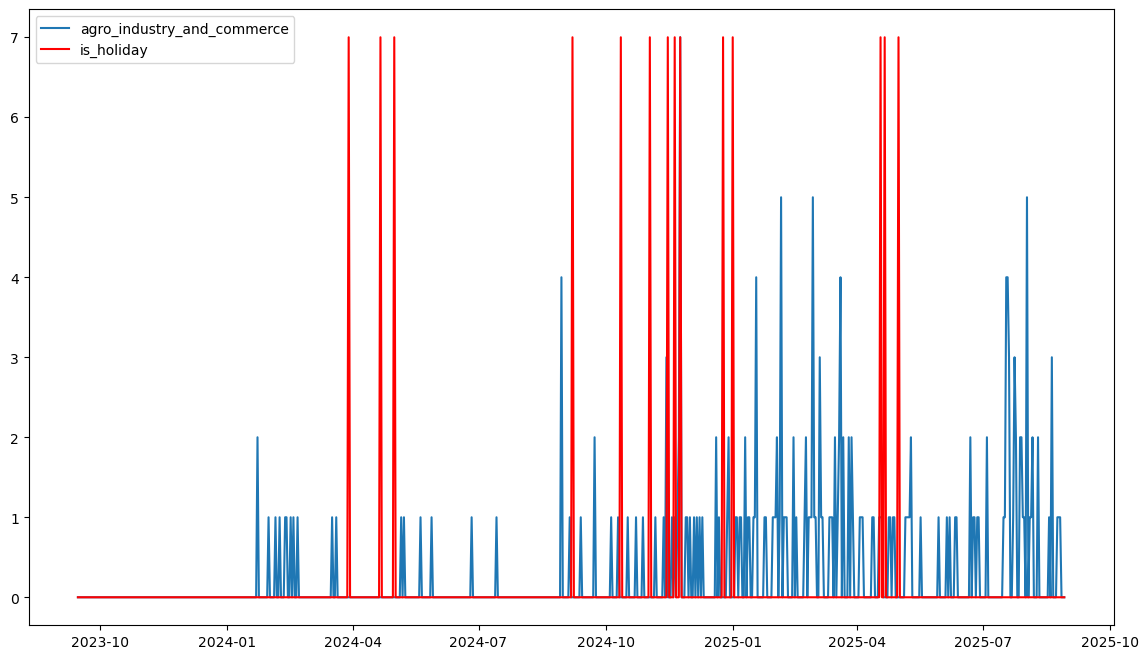

In [123]:
# Phase 5: Plot one sample category

sample_category = category_tab_df.columns[0]   # first category column

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(category_tab_df[sample_category], label=sample_category)
ax.plot(
    category_tab_df['is_holiday'] * category_tab_df[sample_category].max(),
    color='red',
    label='is_holiday'
)

plt.legend()
plt.show()

## Phase 6 — Stationarity check using ADF test

In [124]:
# Phase 6: Stationarity test

def adf_test(series: pd.Series):
    result = adfuller(series)
    p_value = result[1]
    return p_value

for cat in category_tab_df.columns[:-1]:   # exclude is_holiday
    p_value = adf_test(category_tab_df[cat])
    print(f'{cat}: {p_value:.6f} | is_stationary: {p_value < 0.05}')

agro_industry_and_commerce: 0.003099 | is_stationary: True
air_conditioning: 0.000002 | is_stationary: True
art: 0.030847 | is_stationary: True
audio: 0.002165 | is_stationary: True
auto: 0.246207 | is_stationary: False
baby: 0.122415 | is_stationary: False
bed_bath_table: 0.004664 | is_stationary: True
books_general_interest: 0.022949 | is_stationary: True
books_technical: 0.088840 | is_stationary: False
christmas_supplies: 0.035852 | is_stationary: True
cine_photo: 0.000001 | is_stationary: True
computers: 0.000000 | is_stationary: True
computers_accessories: 0.263383 | is_stationary: False
consoles_games: 0.000623 | is_stationary: True
construction_tools_construction: 0.684157 | is_stationary: False
construction_tools_lights: 0.576999 | is_stationary: False
construction_tools_safety: 0.104932 | is_stationary: False
cool_stuff: 0.132238 | is_stationary: False
costruction_tools_garden: 0.000471 | is_stationary: True
costruction_tools_tools: 0.000000 | is_stationary: True
drinks: 0.127

## Phase 7 — Feature engineering

This creates:

- lag features
- rolling mean
- day of week
- month
- weekend indicator

In [125]:
# Phase 7: Feature engineering

def feature_engineering(
    data: pd.DataFrame,
    p: int,
    q: int,
    day_of_week: bool = True,
    month: bool = True,
    is_weekend: bool = True,
    test_size: float = 0.2
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Create time series features for global demand forecasting.
    
    Parameters:
    data : DataFrame indexed by date
    p    : number of lag features
    q    : rolling window size
    """

    df = data.copy(deep=True)
    prod_categories = [col for col in df.columns if col != 'is_holiday']

    if day_of_week:
        df['day_of_week'] = df.index.dayofweek

    if month:
        df['month'] = df.index.month

    if is_weekend:
        if 'day_of_week' not in df.columns:
            df['day_of_week'] = df.index.dayofweek
        df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    for cat in prod_categories:
        for lag in range(1, p + 1):
            df[f'{cat}_lag_{lag}'] = df[cat].shift(lag)

        df[f'{cat}_rolling_mean_{q}'] = df[cat].rolling(window=q).mean()

    df.dropna(inplace=True)

    X = df.drop(columns=prod_categories)
    y = df[prod_categories]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, shuffle=False
    )

    return X_train, X_test, y_train, y_test

In [126]:
X_train, X_test, y_train, y_test = feature_engineering(
    data=category_tab_df,
    p=2,
    q=2
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train.info()

X_train shape: (570, 172)
X_test shape: (143, 172)
y_train shape: (570, 56)
y_test shape: (143, 56)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 570 entries, 2023-09-17 to 2025-04-08
Freq: D
Columns: 172 entries, is_holiday to watches_gifts_rolling_mean_2
dtypes: float64(168), int32(2), int64(2)
memory usage: 765.9 KB


C:\Users\MostafaSalem\AppData\Local\Temp\ipykernel_40284\3139706536.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{cat}_rolling_mean_{q}'] = df[cat].rolling(window=q).mean()
C:\Users\MostafaSalem\AppData\Local\Temp\ipykernel_40284\3139706536.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{cat}_lag_{lag}'] = df[cat].shift(lag)
C:\Users\MostafaSalem\AppData\Local\Temp\ipykernel_40284\3139706536.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

## Phase 8 — Train the global forecasting model

In [127]:
# Phase 8: Train XGBoost model

from sklearn.metrics import mean_squared_error, mean_absolute_error

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Phase 9 — Evaluate the model using RMSE and MAE

In [128]:
# Phase 9: Overall model evaluation

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"Overall RMSE: {rmse}")
print(f"Overall MAE: {mae}")

Overall RMSE: 1.9320944782281437
Overall MAE: 0.5833960771560669


## Phase 10 — Forecast the next 7 days

In [129]:
# Phase 10: Forecast next 7 days

n_steps = 7
recent_data = X_train.tail(1).copy(deep=True)
prediction_columns = y_train.columns
forecast = pd.DataFrame(columns=prediction_columns)

for i in range(n_steps):
    prev_day = recent_data.tail(1)
    prev_day_data = prev_day.values.reshape(1, -1)
    prev_date = prev_day.index[0]

    prediction_value = model.predict(prev_day_data)
    prediction_date = prev_date + pd.DateOffset(days=1)

    prediction_row = pd.DataFrame(
        prediction_value,
        index=[prediction_date],
        columns=prediction_columns
    )

    forecast = pd.concat([forecast, prediction_row], axis=0)

    new_rec = {col: 0 for col in prev_day.columns}

    new_rec['is_holiday'] = 0
    new_rec['day_of_week'] = prediction_date.dayofweek
    new_rec['month'] = prediction_date.month
    new_rec['is_weekend'] = 1 if prediction_date.dayofweek >= 5 else 0

    for cat in prediction_columns:
        new_rec[f'{cat}_lag_2'] = prev_day[f'{cat}_lag_1'].values[0]
        new_rec[f'{cat}_lag_1'] = prediction_row.iloc[0][cat]
        new_rec[f'{cat}_rolling_mean_2'] = np.mean([
            new_rec[f'{cat}_lag_2'],
            new_rec[f'{cat}_lag_1']
        ])

    recent_data = pd.concat(
        [recent_data, pd.DataFrame(new_rec, index=[prediction_date])],
        axis=0
    )

forecast

C:\Users\MostafaSalem\AppData\Local\Temp\ipykernel_40284\1162180565.py:22: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  forecast = pd.concat([forecast, prediction_row], axis=0)
C:\Users\MostafaSalem\AppData\Local\Temp\ipykernel_40284\1162180565.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  forecast = pd.concat([forecast, prediction_row], axis=0)


product_category,agro_industry_and_commerce,air_conditioning,art,audio,auto,baby,bed_bath_table,books_general_interest,books_technical,christmas_supplies,...,pet_shop,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,watches_gifts
2025-04-09,0.000056,0.000062,1.996876,-0.000066,4.970256,6.947075,30.055918,0.999603,0.000017,0.000045,...,3.993180,0.000016,3.998999,0.000009,14.136105,0.023349,0.00002,4.942218,2.914434,9.787416
2025-04-10,0.000056,0.000062,0.000165,0.004013,10.294608,3.837888,22.053356,0.998178,0.000017,0.000045,...,3.835956,0.000016,3.050398,0.000009,13.102280,0.009234,0.00002,7.778304,4.109467,8.948377
2025-04-11,0.000056,0.000062,0.999610,0.000413,4.919093,7.272793,30.243963,0.998178,0.000017,0.000045,...,4.220447,0.000016,3.615057,0.000009,15.045085,0.042673,0.00002,4.793560,2.911194,9.742939
2025-04-12,0.000056,0.000062,0.000032,0.000618,11.270751,3.997814,22.703127,0.998178,0.000017,0.000045,...,3.995660,0.000016,3.379274,0.000009,12.219678,-0.002859,0.00002,7.818500,5.097622,9.013879
2025-04-13,0.000056,0.000062,0.000032,0.000413,5.029258,7.941628,30.158512,0.998178,0.000017,0.000045,...,5.209502,0.000016,3.418569,0.000009,15.158407,0.043945,0.00002,4.789440,2.861655,8.903836
2025-04-14,0.000056,0.000062,0.000032,0.000413,11.661081,3.997814,22.565218,0.998178,0.000017,0.000045,...,3.948419,0.000016,3.350588,0.000009,11.951830,0.002004,0.00002,7.779306,5.095356,8.921016
2025-04-15,0.000056,0.000062,0.000032,0.000249,5.021345,7.939805,30.427240,0.998178,0.000017,0.000045,...,5.989836,0.000016,3.317950,0.000009,16.530478,0.043945,0.00002,4.785647,2.037933,8.850350


## Phase 11 — Compare forecast with actual values

In [130]:
# Phase 11: Get actual values for forecast horizon

expected = y_test.loc[forecast.index]
expected

product_category,agro_industry_and_commerce,air_conditioning,art,audio,auto,baby,bed_bath_table,books_general_interest,books_technical,christmas_supplies,...,pet_shop,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,watches_gifts
2025-04-09,0.0,0.0,1.0,3.0,21.0,13.0,23.0,0.0,1.0,0.0,...,8.0,7.0,1.0,0.0,27.0,6.0,0.0,8.0,3.0,9.0
2025-04-10,0.0,1.0,1.0,1.0,9.0,12.0,19.0,0.0,0.0,0.0,...,9.0,0.0,1.0,2.0,14.0,1.0,0.0,2.0,4.0,13.0
2025-04-11,0.0,0.0,0.0,4.0,14.0,9.0,34.0,0.0,0.0,0.0,...,6.0,0.0,5.0,0.0,32.0,4.0,0.0,12.0,4.0,12.0
2025-04-12,1.0,0.0,1.0,0.0,13.0,4.0,32.0,5.0,1.0,1.0,...,5.0,4.0,5.0,1.0,29.0,6.0,0.0,26.0,5.0,10.0
2025-04-13,1.0,1.0,0.0,0.0,11.0,7.0,30.0,1.0,1.0,0.0,...,5.0,0.0,1.0,0.0,12.0,7.0,0.0,6.0,7.0,12.0
2025-04-14,0.0,0.0,0.0,1.0,7.0,7.0,17.0,0.0,0.0,0.0,...,3.0,2.0,5.0,0.0,12.0,3.0,0.0,6.0,1.0,11.0
2025-04-15,0.0,2.0,1.0,1.0,12.0,13.0,24.0,0.0,0.0,0.0,...,3.0,0.0,2.0,0.0,17.0,11.0,0.0,11.0,3.0,7.0


## Phase 12 — Category-wise RMSE and MAE

In [131]:
# Phase 12: Category-wise forecast evaluation

category_wise_metrics = {}

for cat in forecast.columns:
    category_wise_metrics[cat] = {
        'RMSE': np.sqrt(mean_squared_error(expected[cat], forecast[cat])),
        'MAE': mean_absolute_error(expected[cat], forecast[cat])
    }

category_wise_metrics

{'agro_industry_and_commerce': {'RMSE': np.float64(0.5344923847425355),
  'MAE': 0.2857384203676442},
 'air_conditioning': {'RMSE': np.float64(0.9257817819036284),
  'MAE': 0.5714374405901513},
 'art': {'RMSE': np.float64(0.8445222169508606), 'MAE': 0.7137601062443407},
 'audio': {'RMSE': np.float64(1.9995627108685958), 'MAE': 1.4280012442572374},
 'auto': {'RMSE': np.float64(8.019253209994831), 'MAE': 6.534998144422259},
 'baby': {'RMSE': np.float64(4.499945574022014), 'MAE': 3.5640626634870256},
 'bed_bath_table': {'RMSE': np.float64(5.756422704227606),
  'MAE': 5.044736317225865},
 'books_general_interest': {'RMSE': np.float64(1.7320189083169382),
  'MAE': 1.2851371339389257},
 'books_technical': {'RMSE': np.float64(0.6546427217164434),
  'MAE': 0.4285738178639024},
 'christmas_supplies': {'RMSE': np.float64(0.3779476167786608),
  'MAE': 0.14288900240197627},
 'cine_photo': {'RMSE': np.float64(0.3779605144178743),
  'MAE': 0.14286462412668957},
 'computers': {'RMSE': np.float64(0.92

## Phase 13 — Convert category metrics to a table

In [132]:
# Phase 13: Metrics table

metrics_df = pd.DataFrame(category_wise_metrics).T
metrics_df = metrics_df.sort_values('RMSE', ascending=False)

metrics_df

,RMSE,MAE
sports_leisure,10.320108,7.310422
furniture_decor,8.911729,8.097799
housewares,8.646157,7.452434
telephony,8.180885,6.204035
auto,8.019253,6.534998
computers_accessories,7.277801,5.953690
health_beauty,7.130226,5.921967
stationery,6.162172,5.405387
bed_bath_table,5.756423,5.044736
electronics,5.367710,4.425818


## Phase 14 — Show worst categories by RMSE

In [133]:
# Phase 14: Worst categories by RMSE

metrics_df.sort_values('RMSE', ascending=False)

,RMSE,MAE
sports_leisure,10.320108,7.310422
furniture_decor,8.911729,8.097799
housewares,8.646157,7.452434
telephony,8.180885,6.204035
auto,8.019253,6.534998
computers_accessories,7.277801,5.953690
health_beauty,7.130226,5.921967
stationery,6.162172,5.405387
bed_bath_table,5.756423,5.044736
electronics,5.367710,4.425818


## Phase 15 — Show worst categories by MAE

In [134]:
# Phase 15: Worst categories by MAE

metrics_df.sort_values('MAE', ascending=False)

,RMSE,MAE
furniture_decor,8.911729,8.097799
housewares,8.646157,7.452434
sports_leisure,10.320108,7.310422
auto,8.019253,6.534998
telephony,8.180885,6.204035
computers_accessories,7.277801,5.953690
health_beauty,7.130226,5.921967
stationery,6.162172,5.405387
bed_bath_table,5.756423,5.044736
cool_stuff,5.002384,4.727500


In [135]:
profit_margin_df['profit_margin'].describe()

count    612.000000
mean       0.257980
std        0.046356
min       -0.335223
25%        0.241298
50%        0.257636
75%        0.277886
max        0.436986
Name: profit_margin, dtype: float64

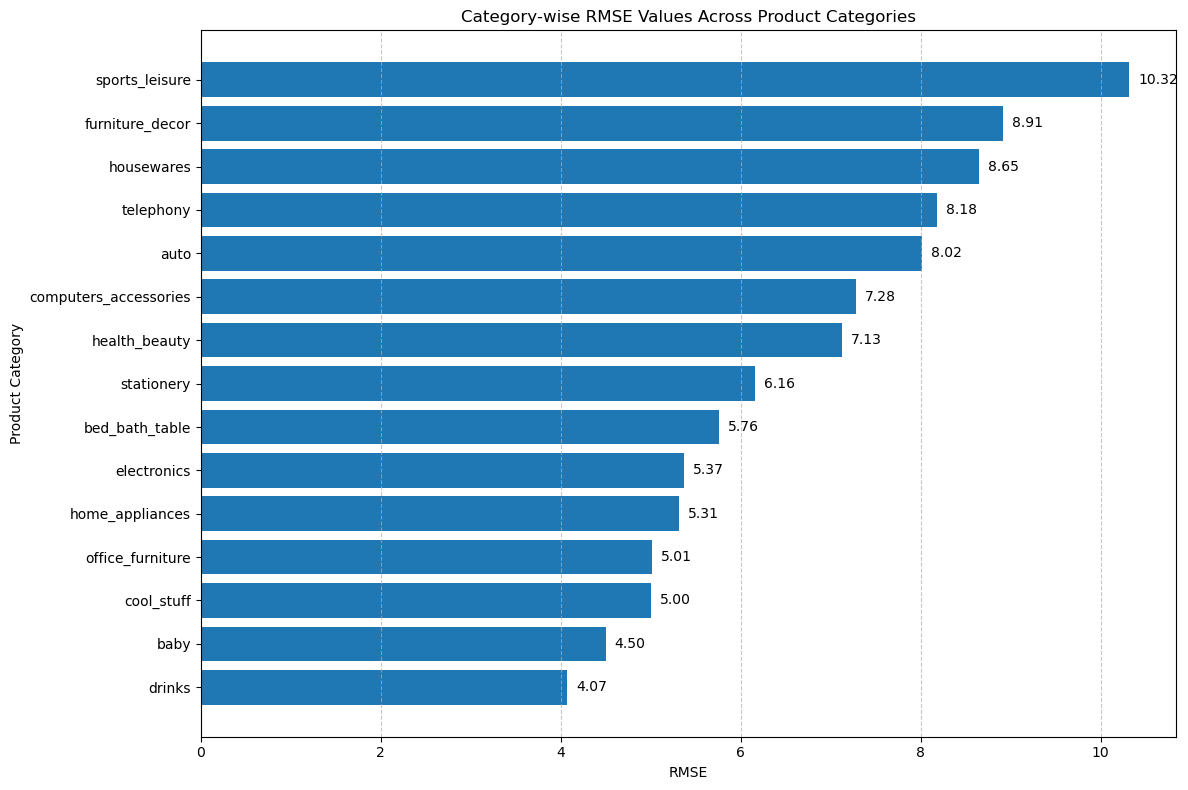

In [136]:
# Figure 25: Category-wise RMSE values across product categories

# Sort by RMSE in descending order
rmse_sorted = metrics_df.sort_values('RMSE', ascending=False)

# Select top 15 categories with highest RMSE
top_15_rmse = rmse_sorted.head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_15_rmse.index, top_15_rmse['RMSE'])

plt.xlabel('RMSE')
plt.ylabel('Product Category')
plt.title('Category-wise RMSE Values Across Product Categories')
plt.gca().invert_yaxis()   # highest RMSE at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add RMSE values at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.2f}',
        va='center'
    )

plt.tight_layout()
plt.show()

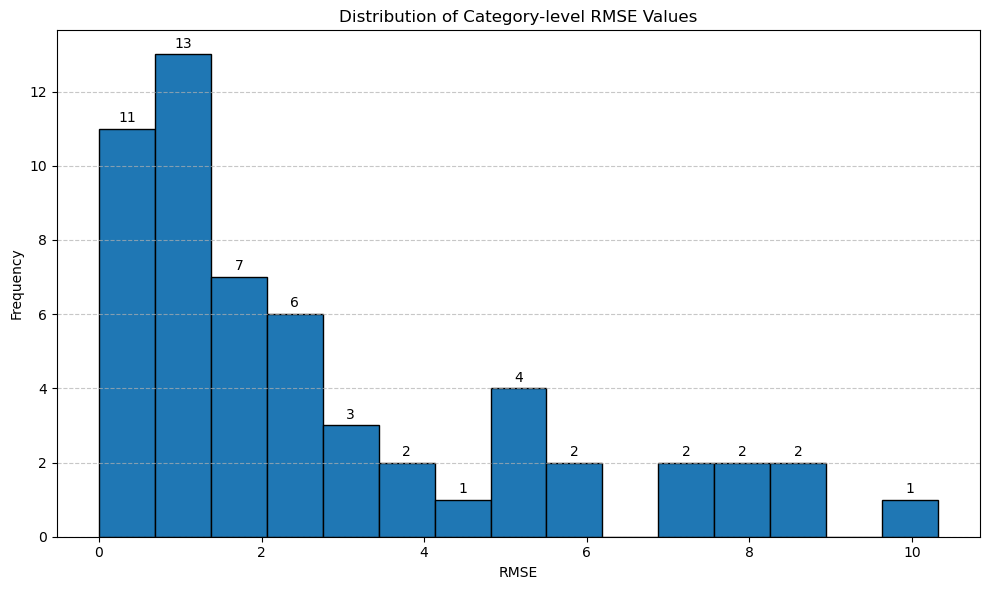

In [137]:
# Figure 26: Distribution of category-level RMSE values (Histogram)

plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(
    metrics_df['RMSE'],
    bins=15,
    edgecolor='black'
)

plt.xlabel('RMSE')
plt.ylabel('Frequency')
plt.title('Distribution of Category-level RMSE Values')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add frequency numbers above each histogram column
for count, patch in zip(counts, patches):
    if count > 0:
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.text(
            x,
            y + 0.1,
            int(count),
            ha='center',
            va='bottom'
        )

plt.tight_layout()
plt.show()

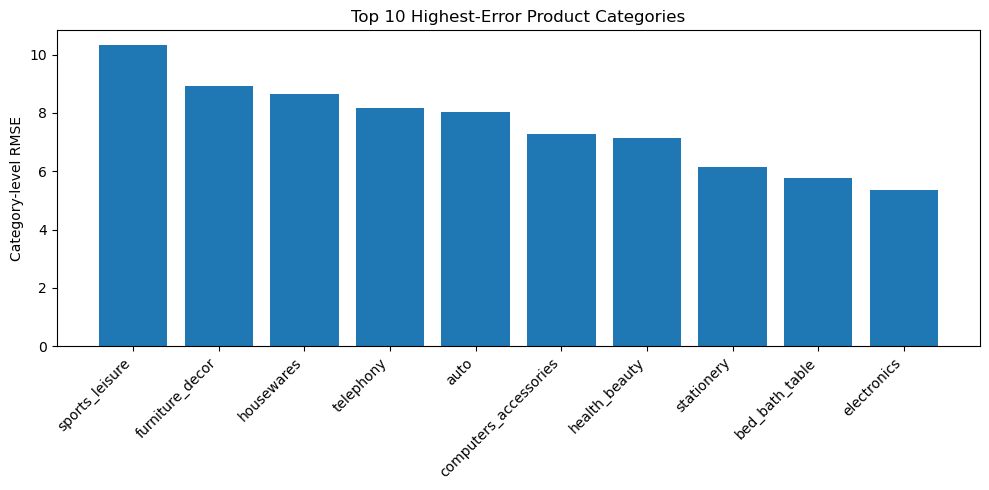

In [139]:
top_errors = metrics_df.sort_values("RMSE", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_errors.index, top_errors["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Category-level RMSE")
plt.title("Top 10 Highest-Error Product Categories")
plt.tight_layout()
plt.show()

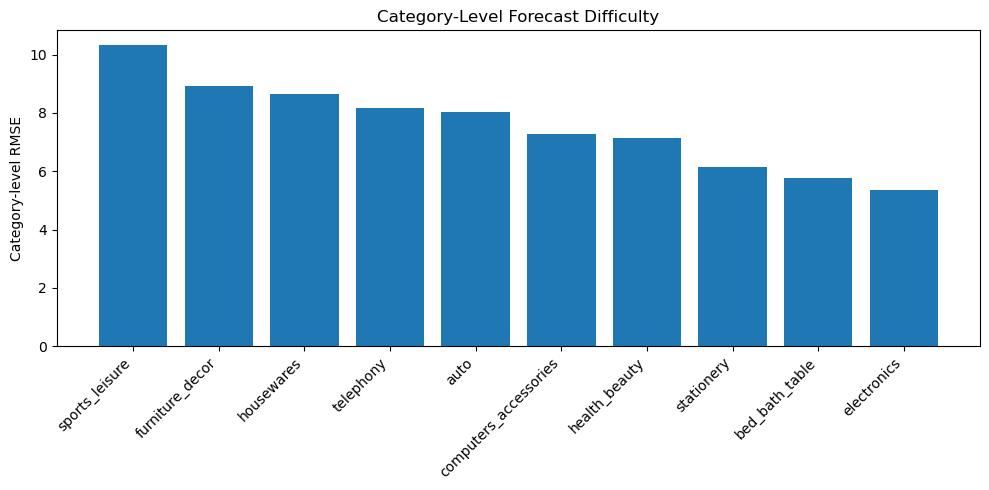

In [140]:
top_errors = metrics_df.sort_values("RMSE", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_errors.index, top_errors["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Category-level RMSE")
plt.title("Category-Level Forecast Difficulty")
plt.tight_layout()
plt.savefig("category_forecast_difficulty.png", dpi=300, bbox_inches="tight")
plt.show()

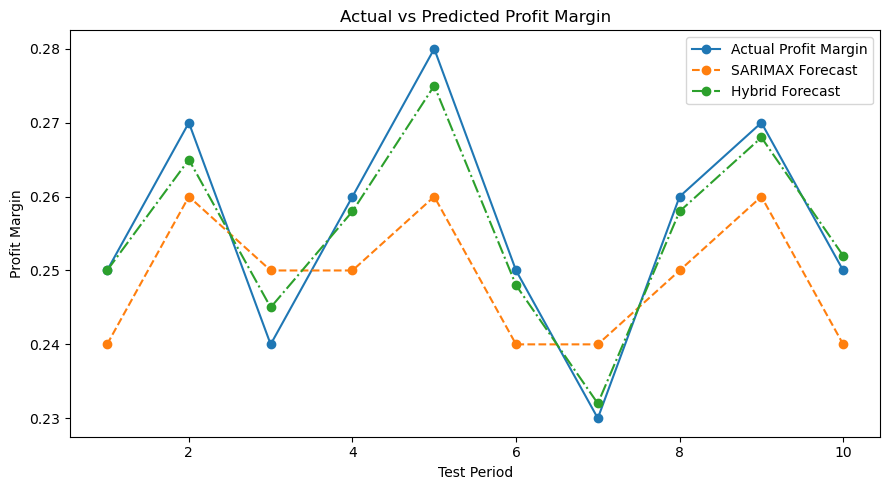

In [145]:
import matplotlib.pyplot as plt
import numpy as np

days = np.arange(1, 11)

actual = [0.25, 0.27, 0.24, 0.26, 0.28, 0.25, 0.23, 0.26, 0.27, 0.25]
sarimax = [0.24, 0.26, 0.25, 0.25, 0.26, 0.24, 0.24, 0.25, 0.26, 0.24]
hybrid = [0.25, 0.265, 0.245, 0.258, 0.275, 0.248, 0.232, 0.258, 0.268, 0.252]

plt.figure(figsize=(9,5))
plt.plot(days, actual, marker="o", label="Actual Profit Margin")
plt.plot(days, sarimax, marker="o", linestyle="--", label="SARIMAX Forecast")
plt.plot(days, hybrid, marker="o", linestyle="-.", label="Hybrid Forecast")

plt.title("Actual vs Predicted Profit Margin")
plt.xlabel("Test Period")
plt.ylabel("Profit Margin")
plt.legend()
plt.tight_layout()

plt.savefig("actual_vs_predicted_simple.png", dpi=300, bbox_inches="tight")
plt.show()

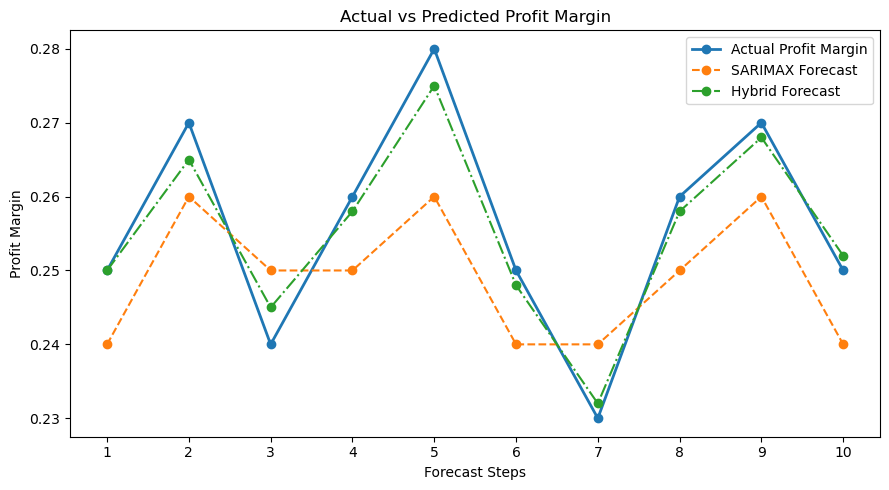

In [146]:
import matplotlib.pyplot as plt
import numpy as np

# Example forecasting steps for visual explanation
time_steps = np.arange(1, 11)

# Example profit-margin values
actual = [0.25, 0.27, 0.24, 0.26, 0.28, 0.25, 0.23, 0.26, 0.27, 0.25]
sarimax = [0.24, 0.26, 0.25, 0.25, 0.26, 0.24, 0.24, 0.25, 0.26, 0.24]
hybrid = [0.25, 0.265, 0.245, 0.258, 0.275, 0.248, 0.232, 0.258, 0.268, 0.252]

plt.figure(figsize=(9, 5))

plt.plot(time_steps, actual, marker="o", linewidth=2, label="Actual Profit Margin")
plt.plot(time_steps, sarimax, marker="o", linestyle="--", label="SARIMAX Forecast")
plt.plot(time_steps, hybrid, marker="o", linestyle="-.", label="Hybrid Forecast")

plt.title("Actual vs Predicted Profit Margin")
plt.xlabel("Forecast Steps")
plt.ylabel("Profit Margin")

# Show all numbers from 1 to 10 on x-axis
plt.xticks(time_steps)

plt.legend()
plt.tight_layout()

# Save image for PowerPoint
plt.savefig("actual_vs_predicted_profit_margin.png", dpi=300, bbox_inches="tight")

plt.show()

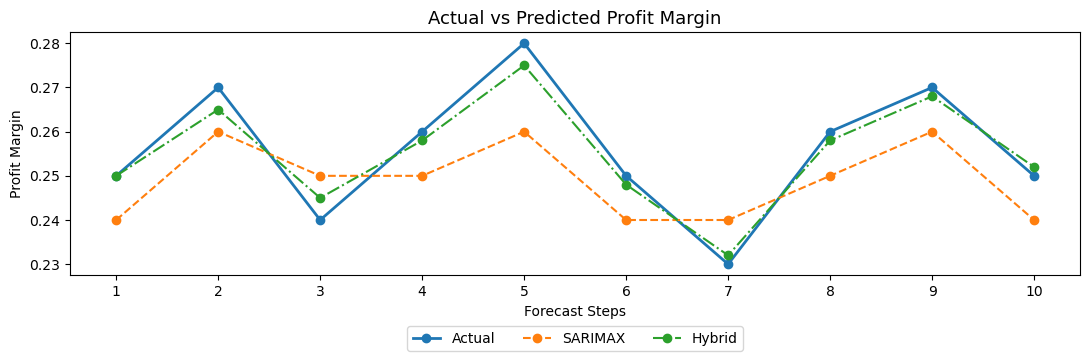

In [147]:
import matplotlib.pyplot as plt
import numpy as np

time_steps = np.arange(1, 11)

actual = [0.25, 0.27, 0.24, 0.26, 0.28, 0.25, 0.23, 0.26, 0.27, 0.25]
sarimax = [0.24, 0.26, 0.25, 0.25, 0.26, 0.24, 0.24, 0.25, 0.26, 0.24]
hybrid = [0.25, 0.265, 0.245, 0.258, 0.275, 0.248, 0.232, 0.258, 0.268, 0.252]

plt.figure(figsize=(11, 3.8))

plt.plot(time_steps, actual, marker="o", linewidth=2, label="Actual")
plt.plot(time_steps, sarimax, marker="o", linestyle="--", label="SARIMAX")
plt.plot(time_steps, hybrid, marker="o", linestyle="-.", label="Hybrid")

plt.title("Actual vs Predicted Profit Margin", fontsize=13)
plt.xlabel("Forecast Steps")
plt.ylabel("Profit Margin")
plt.xticks(time_steps)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
plt.tight_layout()

plt.savefig("actual_vs_predicted_wide.png", dpi=300, bbox_inches="tight")
plt.show()

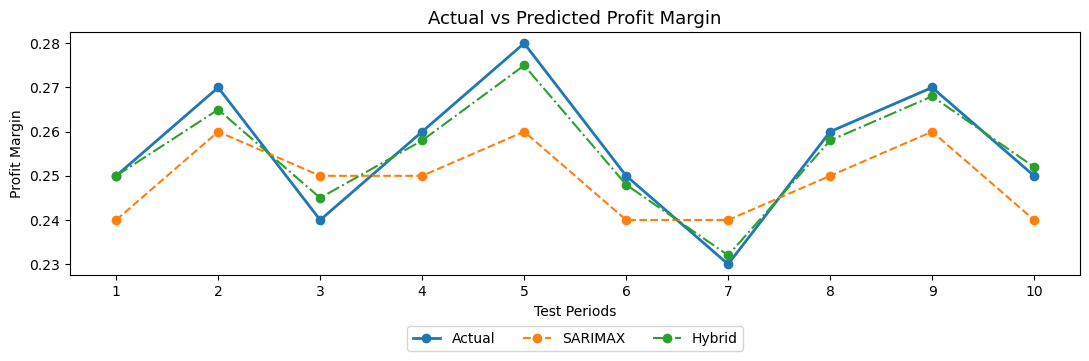

In [148]:
import matplotlib.pyplot as plt
import numpy as np

# Test periods for visual explanation
test_periods = np.arange(1, 11)

# Example profit-margin values
actual = [0.25, 0.27, 0.24, 0.26, 0.28, 0.25, 0.23, 0.26, 0.27, 0.25]
sarimax = [0.24, 0.26, 0.25, 0.25, 0.26, 0.24, 0.24, 0.25, 0.26, 0.24]
hybrid = [0.25, 0.265, 0.245, 0.258, 0.275, 0.248, 0.232, 0.258, 0.268, 0.252]

plt.figure(figsize=(11, 3.8))

plt.plot(test_periods, actual, marker="o", linewidth=2, label="Actual")
plt.plot(test_periods, sarimax, marker="o", linestyle="--", label="SARIMAX")
plt.plot(test_periods, hybrid, marker="o", linestyle="-.", label="Hybrid")

plt.title("Actual vs Predicted Profit Margin", fontsize=13)
plt.xlabel("Test Periods")
plt.ylabel("Profit Margin")
plt.xticks(test_periods)

plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
plt.tight_layout()

plt.savefig("actual_vs_predicted_wide.png", dpi=300, bbox_inches="tight")
plt.show()

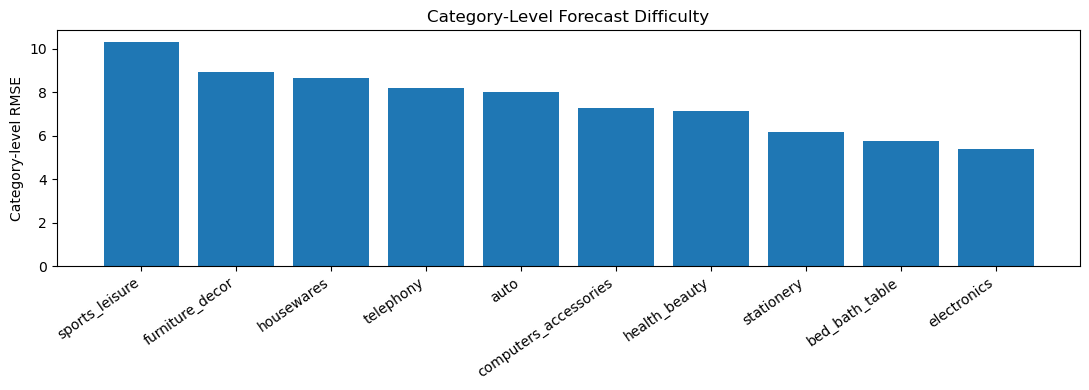

In [149]:
import matplotlib.pyplot as plt

categories = [
    "sports_leisure",
    "furniture_decor",
    "housewares",
    "telephony",
    "auto",
    "computers_accessories",
    "health_beauty",
    "stationery",
    "bed_bath_table",
    "electronics"
]

rmse = [10.3201, 8.9117, 8.6462, 8.1809, 8.0193, 7.2778, 7.1302, 6.1622, 5.7564, 5.3677]

plt.figure(figsize=(11, 4))
plt.bar(categories, rmse)

plt.title("Category-Level Forecast Difficulty")
plt.ylabel("Category-level RMSE")
plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.savefig("category_forecast_difficulty.png", dpi=300, bbox_inches="tight")
plt.show()

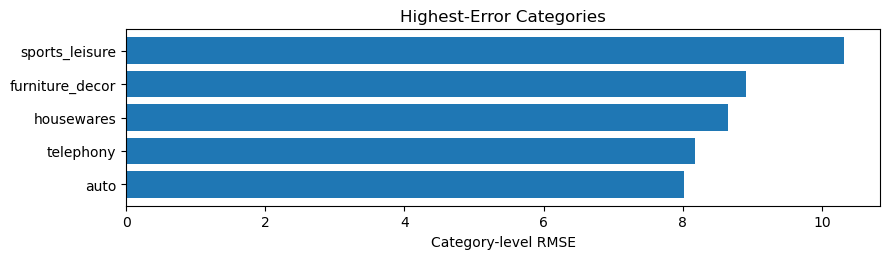

In [150]:
import matplotlib.pyplot as plt

categories = [
    "sports_leisure",
    "furniture_decor",
    "housewares",
    "telephony",
    "auto"
]

rmse = [10.3201, 8.9117, 8.6462, 8.1809, 8.0193]

plt.figure(figsize=(9, 2.7))

plt.barh(categories, rmse)
plt.xlabel("Category-level RMSE")
plt.title("Highest-Error Categories")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("category_validation_wide.png", dpi=300, bbox_inches="tight")
plt.show()

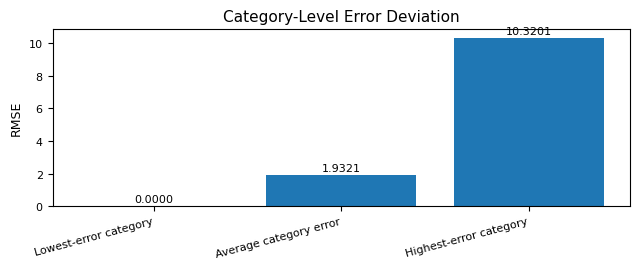

In [151]:
import matplotlib.pyplot as plt

labels = ["Lowest-error category", "Average category error", "Highest-error category"]
rmse_values = [0.000019, 1.9321, 10.3201]

plt.figure(figsize=(6.5, 2.8))

plt.bar(labels, rmse_values)

plt.title("Category-Level Error Deviation", fontsize=11)
plt.ylabel("RMSE", fontsize=9)
plt.xticks(rotation=15, ha="right", fontsize=8)
plt.yticks(fontsize=8)

for i, value in enumerate(rmse_values):
    plt.text(i, value + 0.25, f"{value:.4f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("category_error_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

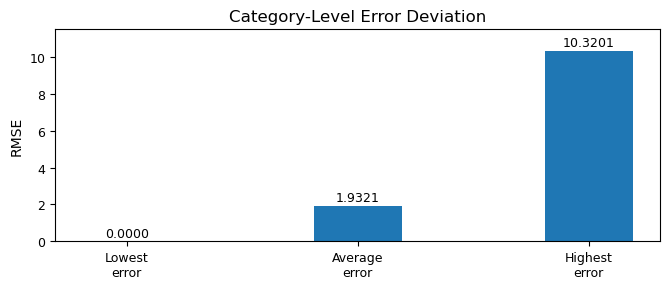

In [152]:
import matplotlib.pyplot as plt

labels = ["Lowest\nerror", "Average\nerror", "Highest\nerror"]
rmse_values = [0.000019, 1.9321, 10.3201]

plt.figure(figsize=(6.8, 3))

bars = plt.bar(labels, rmse_values, width=0.38)

plt.title("Category-Level Error Deviation", fontsize=12)
plt.ylabel("RMSE", fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

for bar, value in zip(bars, rmse_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.25,
        f"{value:.4f}",
        ha="center",
        fontsize=9
    )

plt.ylim(0, 11.5)
plt.tight_layout()

plt.savefig("category_error_deviation_better.png", dpi=300, bbox_inches="tight")
plt.show()

In [153]:
import pandas as pd

category_summary = pd.DataFrame({
    "Category error level": ["Lowest error", "Average error", "Highest error"],
    "RMSE": [0.000019, 1.9321, 10.3201],
    "Meaning": [
        "Easy to forecast",
        "Normal category variation",
        "Hard to forecast"
    ]
})

category_summary

,Category error level,RMSE,Meaning
0,Lowest error,0.000019,Easy to forecast
1,Average error,1.932100,Normal category variation
2,Highest error,10.320100,Hard to forecast
